In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install yfinance pandas numpy sqlalchemy ta finbert-embedding transformers scikit-learn xgboost statsmodels langchain langchain-community sentence-transformers faiss-cpu newsapi-python requests matplotlib seaborn plotly torch --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 72.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-clou

In [14]:
import os
import sqlite3
import warnings
import logging
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
logger = logging.getLogger(__name__)

DB_PATH  = "stock_intelligence.db"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

INDIAN_STOCKS = {
    # IT & Technology
    "TCS":               "TCS.NS",
    "Infosys":           "INFY.NS",
    "Wipro":             "WIPRO.NS",
    "HCL Tech":          "HCLTECH.NS",
    "Tech Mahindra":     "TECHM.NS",
    "Mphasis":           "MPHASIS.NS",
    "LTIMindtree":       "LTIMINDTREE.NS",
    "Persistent":        "PERSISTENT.NS",
    "Coforge":           "COFORGE.NS",
    "Zensar":            "ZENSARTECH.NS",

    # Banking
    "HDFC Bank":         "HDFCBANK.NS",
    "ICICI Bank":        "ICICIBANK.NS",
    "Axis Bank":         "AXISBANK.NS",
    "SBI":               "SBIN.NS",
    "Kotak Bank":        "KOTAKBANK.NS",
    "IndusInd Bank":     "INDUSINDBK.NS",
    "Yes Bank":          "YESBANK.NS",
    "Bank of Baroda":    "BANKBARODA.NS",
    "PNB":               "PNB.NS",
    "Federal Bank":      "FEDERALBNK.NS",
    "IDFC First Bank":   "IDFCFIRSTB.NS",
    "Canara Bank":       "CANBK.NS",

    # Financial Services & NBFC
    "Bajaj Finance":     "BAJFINANCE.NS",
    "Bajaj Finserv":     "BAJAJFINSV.NS",
    "Piramal Ent":       "PIRAMALENT.NS",
    "Muthoot Finance":   "MUTHOOTFIN.NS",
    "Cholamandalam":     "CHOLAFIN.NS",
    "Shriram Finance":   "SHRIRAMFIN.NS",
    "HDFC Life":         "HDFCLIFE.NS",
    "SBI Life":          "SBILIFE.NS",
    "ICICI Prudential":  "ICICIPRULI.NS",
    "ICICI Lombard":     "ICICIGI.NS",
    "BSE":               "BSE.NS",
    "MCX":               "MCX.NS",
    "CDSL":              "CDSL.NS",

    # Analytics & IT Services
    "Happiest Minds":    "HAPPSTMNDS.NS",
    "NIIT Learning":     "NIITLTD.NS",

    # Ecommerce & Fintech
    "Zomato":            "ZOMATO.BO",
    "Paytm":             "PAYTM.NS",
    "PB Fintech":        "POLICYBZR.NS",
    "Nykaa":             "NYKAA.NS",
    "Delhivery":         "DELHIVERY.NS",
    "Nazara Tech":       "NAZARA.NS",

    # Conglomerate & Energy
    "Reliance":          "RELIANCE.NS",
    "Adani Enterprises": "ADANIENT.NS",
    "Adani Ports":       "ADANIPORTS.NS",
    "Adani Green":       "ADANIGREEN.NS",
    "Adani Power":       "ADANIPOWER.NS",
    "Tata Power":        "TATAPOWER.NS",
    "NTPC":              "NTPC.NS",
    "PowerGrid":         "POWERGRID.NS",
    "ONGC":              "ONGC.NS",
    "Coal India":        "COALINDIA.NS",
    "BPCL":              "BPCL.NS",
    "IOC":               "IOC.NS",

    # Automobile
    "Maruti":            "MARUTI.NS",
    "Tata Motors":       "TATAMOTORS.NS",
    "M&M":               "M&M.NS",
    "Hero MotoCorp":     "HEROMOTOCO.NS",
    "Bajaj Auto":        "BAJAJ-AUTO.NS",
    "Eicher Motors":     "EICHERMOT.NS",
    "TVS Motor":         "TVSMOTOR.NS",
    "Bosch":             "BOSCHLTD.NS",

    # FMCG & Consumer
    "Hindustan Unilever":"HINDUNILVR.NS",
    "ITC":               "ITC.NS",
    "Nestle India":      "NESTLEIND.NS",
    "Britannia":         "BRITANNIA.NS",
    "Dabur":             "DABUR.NS",
    "Marico":            "MARICO.NS",
    "Godrej Consumer":   "GODREJCP.NS",
    "Colgate":           "COLPAL.NS",
    "Emami":             "EMAMILTD.NS",

    # Pharma & Healthcare
    "Sun Pharma":        "SUNPHARMA.NS",
    "Dr Reddys":         "DRREDDY.NS",
    "Cipla":             "CIPLA.NS",
    "Divis Labs":        "DIVISLAB.NS",
    "Biocon":            "BIOCON.NS",
    "Apollo Hospitals":  "APOLLOHOSP.NS",
    "Max Healthcare":    "MAXHEALTH.NS",
    "Fortis":            "FORTIS.NS",
    "Laurus Labs":       "LAURUSLABS.NS",

    # Infrastructure & Capital Goods
    "L&T":               "LT.NS",
    "Siemens":           "SIEMENS.NS",
    "ABB India":         "ABB.NS",
    "Havells":           "HAVELLS.NS",
    "BEL":               "BEL.NS",
    "HAL":               "HAL.NS",

    # Cement & Materials
    "UltraTech Cement":  "ULTRACEMCO.NS",
    "Shree Cement":      "SHREECEM.NS",
    "ACC":               "ACC.NS",
    "Ambuja Cement":     "AMBUJACEM.NS",
    "JSW Steel":         "JSWSTEEL.NS",
    "Tata Steel":        "TATASTEEL.NS",
    "Hindalco":          "HINDALCO.NS",
    "Vedanta":           "VEDL.NS",

    # Real Estate
    "DLF":               "DLF.NS",
    "Godrej Properties": "GODREJPROP.NS",
    "Prestige Estates":  "PRESTIGE.NS",
    "Oberoi Realty":     "OBEROIRLTY.NS",

    # Consumer Retail & Lifestyle
    "Asian Paints":      "ASIANPAINT.NS",
    "Titan":             "TITAN.NS",
    "Trent":             "TRENT.NS",
    "DMart":             "DMART.NS",
    "Jubilant Foods":    "JUBLFOOD.NS",
}

TICKER_LIST = list(INDIAN_STOCKS.values())
START_DATE  = (datetime.today() - timedelta(days=5 * 365)).strftime("%Y-%m-%d")
END_DATE    = datetime.today().strftime("%Y-%m-%d")

print(f"Total tickers  : {len(TICKER_LIST)}")
print(f"Date range     : {START_DATE} → {END_DATE}")
print(f"DB path        : {DB_PATH}")

Total tickers  : 104
Date range     : 2021-06-25 → 2026-06-24
DB path        : stock_intelligence.db


In [10]:
def create_database(db_path: str) -> None:
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()

    cur.executescript("""
        PRAGMA journal_mode = WAL;
        PRAGMA foreign_keys = ON;

        CREATE TABLE IF NOT EXISTS stocks (
            stock_id    INTEGER PRIMARY KEY AUTOINCREMENT,
            ticker      TEXT    NOT NULL UNIQUE,
            company     TEXT    NOT NULL,
            exchange    TEXT    NOT NULL DEFAULT 'NSE',
            sector      TEXT,
            created_at  TEXT    NOT NULL DEFAULT (datetime('now'))
        );

        CREATE TABLE IF NOT EXISTS prices (
            price_id    INTEGER PRIMARY KEY AUTOINCREMENT,
            stock_id    INTEGER NOT NULL REFERENCES stocks(stock_id),
            date        TEXT    NOT NULL,
            open        REAL,
            high        REAL,
            low         REAL,
            close       REAL    NOT NULL,
            adj_close   REAL,
            volume      INTEGER,
            UNIQUE(stock_id, date)
        );

        CREATE TABLE IF NOT EXISTS news (
            news_id     INTEGER PRIMARY KEY AUTOINCREMENT,
            stock_id    INTEGER REFERENCES stocks(stock_id),
            ticker      TEXT,
            headline    TEXT    NOT NULL,
            source      TEXT,
            published_at TEXT,
            url         TEXT,
            fetched_at  TEXT    NOT NULL DEFAULT (datetime('now'))
        );

        CREATE TABLE IF NOT EXISTS sentiment_scores (
            score_id    INTEGER PRIMARY KEY AUTOINCREMENT,
            news_id     INTEGER NOT NULL REFERENCES news(news_id),
            stock_id    INTEGER NOT NULL REFERENCES stocks(stock_id),
            date        TEXT    NOT NULL,
            positive    REAL    NOT NULL DEFAULT 0.0,
            negative    REAL    NOT NULL DEFAULT 0.0,
            neutral     REAL    NOT NULL DEFAULT 0.0,
            compound    REAL    NOT NULL DEFAULT 0.0,
            label       TEXT    NOT NULL DEFAULT 'neutral',
            model_used  TEXT    NOT NULL DEFAULT 'finbert',
            scored_at   TEXT    NOT NULL DEFAULT (datetime('now'))
        );

        CREATE INDEX IF NOT EXISTS idx_prices_stock_date   ON prices(stock_id, date);
        CREATE INDEX IF NOT EXISTS idx_news_stock          ON news(stock_id);
        CREATE INDEX IF NOT EXISTS idx_news_published      ON news(published_at);
        CREATE INDEX IF NOT EXISTS idx_sentiment_stock_date ON sentiment_scores(stock_id, date);
    """)

    conn.commit()
    conn.close()
    print("Schema created — 4 tables, indexes applied.")

create_database(DB_PATH)

Schema created — 4 tables, indexes applied.


In [15]:
SECTOR_MAP = {
    # IT & Technology
    "TCS.NS":            "IT",
    "INFY.NS":           "IT",
    "WIPRO.NS":          "IT",
    "HCLTECH.NS":        "IT",
    "TECHM.NS":          "IT",
    "MPHASIS.NS":        "IT",
    "LTIMINDTREE.NS":    "IT",
    "PERSISTENT.NS":     "IT",
    "COFORGE.NS":        "IT",
    "ZENSARTECH.NS":     "IT",

    # Banking
    "HDFCBANK.NS":       "Banking",
    "ICICIBANK.NS":      "Banking",
    "AXISBANK.NS":       "Banking",
    "SBIN.NS":           "Banking",
    "KOTAKBANK.NS":      "Banking",
    "INDUSINDBK.NS":     "Banking",
    "YESBANK.NS":        "Banking",
    "BANKBARODA.NS":     "Banking",
    "PNB.NS":            "Banking",
    "FEDERALBNK.NS":     "Banking",
    "IDFCFIRSTB.NS":     "Banking",
    "CANBK.NS":          "Banking",

    # Financial Services & NBFC
    "BAJFINANCE.NS":     "Financial Services",
    "BAJAJFINSV.NS":     "Financial Services",
    "PIRAMALENT.NS":     "Financial Services",
    "MUTHOOTFIN.NS":     "Financial Services",
    "CHOLAFIN.NS":       "Financial Services",
    "SHRIRAMFIN.NS":     "Financial Services",
    "HDFCLIFE.NS":       "Financial Services",
    "SBILIFE.NS":        "Financial Services",
    "ICICIPRULI.NS":     "Financial Services",
    "ICICIGI.NS":        "Financial Services",
    "BSE.NS":            "Financial Services",
    "MCX.NS":            "Financial Services",
    "CDSL.NS":           "Financial Services",

    # Analytics & IT Services
    "HAPPSTMNDS.NS":     "IT",
    "NIITLTD.NS":        "Education/Analytics",

    # Ecommerce & Fintech
    "ZOMATO.BO":         "Ecommerce/Fintech",
    "PAYTM.NS":          "Ecommerce/Fintech",
    "POLICYBZR.NS":      "Ecommerce/Fintech",
    "NYKAA.NS":          "Ecommerce/Fintech",
    "DELHIVERY.NS":      "Ecommerce/Fintech",
    "NAZARA.NS":         "Ecommerce/Fintech",

    # Conglomerate & Energy
    "RELIANCE.NS":       "Energy/Conglomerate",
    "ADANIENT.NS":       "Conglomerate",
    "ADANIPORTS.NS":     "Infrastructure",
    "ADANIGREEN.NS":     "Energy",
    "ADANIPOWER.NS":     "Energy",
    "TATAPOWER.NS":      "Energy",
    "NTPC.NS":           "Energy",
    "POWERGRID.NS":      "Utilities",
    "ONGC.NS":           "Oil & Gas",
    "COALINDIA.NS":      "Mining",
    "BPCL.NS":           "Oil & Gas",
    "IOC.NS":            "Oil & Gas",

    # Automobile
    "MARUTI.NS":         "Automobile",
    "TATAMOTORS.NS":     "Automobile",
    "M&M.NS":            "Automobile",
    "HEROMOTOCO.NS":     "Automobile",
    "BAJAJ-AUTO.NS":     "Automobile",
    "EICHERMOT.NS":      "Automobile",
    "TVSMOTOR.NS":       "Automobile",
    "BOSCHLTD.NS":       "Automobile",

    # FMCG & Consumer
    "HINDUNILVR.NS":     "FMCG",
    "ITC.NS":            "FMCG",
    "NESTLEIND.NS":      "FMCG",
    "BRITANNIA.NS":      "FMCG",
    "DABUR.NS":          "FMCG",
    "MARICO.NS":         "FMCG",
    "GODREJCP.NS":       "FMCG",
    "COLPAL.NS":         "FMCG",
    "EMAMILTD.NS":       "FMCG",

    # Pharma & Healthcare
    "SUNPHARMA.NS":      "Pharma",
    "DRREDDY.NS":        "Pharma",
    "CIPLA.NS":          "Pharma",
    "DIVISLAB.NS":       "Pharma",
    "BIOCON.NS":         "Pharma",
    "APOLLOHOSP.NS":     "Healthcare",
    "MAXHEALTH.NS":      "Healthcare",
    "FORTIS.NS":         "Healthcare",
    "LAURUSLABS.NS":     "Pharma",

    # Infrastructure & Capital Goods
    "LT.NS":             "Infrastructure",
    "SIEMENS.NS":        "Capital Goods",
    "ABB.NS":            "Capital Goods",
    "HAVELLS.NS":        "Capital Goods",
    "BEL.NS":            "Defence/Electronics",
    "HAL.NS":            "Defence/Aerospace",

    # Cement & Materials
    "ULTRACEMCO.NS":     "Cement",
    "SHREECEM.NS":       "Cement",
    "ACC.NS":            "Cement",
    "AMBUJACEM.NS":      "Cement",
    "JSWSTEEL.NS":       "Steel",
    "TATASTEEL.NS":      "Steel",
    "HINDALCO.NS":       "Metals",
    "VEDL.NS":           "Metals",

    # Real Estate
    "DLF.NS":            "Real Estate",
    "GODREJPROP.NS":     "Real Estate",
    "PRESTIGE.NS":       "Real Estate",
    "OBEROIRLTY.NS":     "Real Estate",

    # Consumer Retail & Lifestyle
    "ASIANPAINT.NS":     "Consumer",
    "TITAN.NS":          "Consumer",
    "TRENT.NS":          "Retail",
    "DMART.NS":          "Retail",
    "JUBLFOOD.NS":       "Retail/QSR",
}

def insert_stock_masters(db_path: str, stocks: dict, sector_map: dict) -> dict:
    conn   = sqlite3.connect(db_path)
    cur    = conn.cursor()
    id_map = {}
    for company, ticker in stocks.items():
        cur.execute("""
            INSERT INTO stocks (ticker, company, exchange, sector)
            VALUES (?, ?, 'NSE', ?)
            ON CONFLICT(ticker) DO UPDATE SET
                company = excluded.company,
                sector  = excluded.sector
        """, (ticker, company, sector_map.get(ticker, "Unknown")))
        cur.execute("SELECT stock_id FROM stocks WHERE ticker = ?", (ticker,))
        id_map[ticker] = cur.fetchone()[0]
    conn.commit()
    conn.close()
    print(f"Inserted/updated {len(id_map)} stock master records.")
    return id_map

STOCK_ID_MAP = insert_stock_masters(DB_PATH, INDIAN_STOCKS, SECTOR_MAP)

conn     = sqlite3.connect(DB_PATH)
df_check = pd.read_sql("""
    SELECT sector, COUNT(*) as count
    FROM stocks
    GROUP BY sector
    ORDER BY count DESC
""", conn)
conn.close()
print("\nStocks by sector:")
print(df_check.to_string(index=False))

Inserted/updated 104 stock master records.

Stocks by sector:
             sector  count
 Financial Services     14
                 IT     12
            Banking     12
               FMCG      9
         Automobile      8
  Ecommerce/Fintech      7
             Pharma      6
        Real Estate      4
             Energy      4
             Cement      4
          Oil & Gas      3
         Healthcare      3
      Capital Goods      3
              Steel      2
             Retail      2
             Metals      2
     Infrastructure      2
           Consumer      2
         Consulting      2
          Utilities      1
         Retail/QSR      1
             Mining      1
Energy/Conglomerate      1
Education/Analytics      1
Defence/Electronics      1
  Defence/Aerospace      1
       Conglomerate      1


In [16]:
def download_prices(ticker: str, start: str, end: str) -> pd.DataFrame:
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if df.empty:
            logger.warning(f"No data returned for {ticker}")
            return pd.DataFrame()
        df         = df.reset_index()
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
        df         = df.rename(columns={
            "Date":   "date",
            "Open":   "open",
            "High":   "high",
            "Low":    "low",
            "Close":  "close",
            "Volume": "volume",
        })
        df["date"]      = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
        df["adj_close"] = df["close"]
        df["ticker"]    = ticker
        return df[["date", "open", "high", "low", "close", "adj_close", "volume", "ticker"]]
    except Exception as e:
        logger.error(f"Failed {ticker}: {e}")
        return pd.DataFrame()

def bulk_insert_prices(db_path: str, df: pd.DataFrame, stock_id: int) -> int:
    if df.empty:
        return 0
    conn   = sqlite3.connect(db_path)
    cur    = conn.cursor()
    rows   = df[["date", "open", "high", "low", "close", "adj_close", "volume"]].values.tolist()
    values = [(stock_id,) + tuple(r) for r in rows]
    cur.executemany("""
        INSERT OR IGNORE INTO prices
            (stock_id, date, open, high, low, close, adj_close, volume)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, values)
    inserted = cur.rowcount
    conn.commit()
    conn.close()
    return inserted

all_price_data = {}
total_rows     = 0

for company, ticker in INDIAN_STOCKS.items():
    df       = download_prices(ticker, START_DATE, END_DATE)
    inserted = bulk_insert_prices(DB_PATH, df, STOCK_ID_MAP[ticker])
    all_price_data[ticker] = df
    total_rows += inserted
    print(f"  {ticker:25s} — {len(df):4d} rows fetched | {inserted:4d} inserted")

print(f"\nTotal price rows in DB: {total_rows:,}")

  TCS.NS                    — 1236 rows fetched |    0 inserted
  INFY.NS                   — 1236 rows fetched |    0 inserted
  WIPRO.NS                  — 1236 rows fetched |    0 inserted
  HCLTECH.NS                — 1236 rows fetched |    0 inserted
  TECHM.NS                  — 1236 rows fetched |    0 inserted
  MPHASIS.NS                — 1236 rows fetched |    0 inserted


2026-06-24 06:21:59,794 — ERROR — 
1 Failed download:
2026-06-24 06:21:59,795 — ERROR — ['LTIMINDTREE.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:21:59,800 — WARNING — No data returned for LTIMINDTREE.NS


  LTIMINDTREE.NS            —    0 rows fetched |    0 inserted
  PERSISTENT.NS             — 1236 rows fetched |    0 inserted
  COFORGE.NS                — 1236 rows fetched |    0 inserted
  ZENSARTECH.NS             — 1236 rows fetched |    0 inserted
  HDFCBANK.NS               — 1236 rows fetched |    0 inserted
  ICICIBANK.NS              — 1236 rows fetched |    0 inserted
  AXISBANK.NS               — 1236 rows fetched |    0 inserted
  SBIN.NS                   — 1236 rows fetched |    0 inserted
  KOTAKBANK.NS              — 1236 rows fetched |    0 inserted
  INDUSINDBK.NS             — 1236 rows fetched |    0 inserted
  YESBANK.NS                — 1236 rows fetched |    0 inserted
  BANKBARODA.NS             — 1236 rows fetched |    0 inserted
  PNB.NS                    — 1236 rows fetched |    0 inserted
  FEDERALBNK.NS             — 1236 rows fetched |    0 inserted
  IDFCFIRSTB.NS             — 1236 rows fetched |    0 inserted
  CANBK.NS                  — 1236 rows 

2026-06-24 06:22:03,337 — ERROR — 
1 Failed download:
2026-06-24 06:22:03,338 — ERROR — ['PIRAMALENT.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:22:03,342 — WARNING — No data returned for PIRAMALENT.NS


  PIRAMALENT.NS             —    0 rows fetched |    0 inserted
  MUTHOOTFIN.NS             — 1236 rows fetched |    0 inserted
  CHOLAFIN.NS               — 1236 rows fetched |    0 inserted
  SHRIRAMFIN.NS             — 1236 rows fetched |    0 inserted
  HDFCLIFE.NS               — 1236 rows fetched |    0 inserted
  SBILIFE.NS                — 1236 rows fetched |    0 inserted
  ICICIPRULI.NS             — 1236 rows fetched |    0 inserted
  ICICIGI.NS                — 1236 rows fetched |    0 inserted
  BSE.NS                    — 1236 rows fetched |    0 inserted
  MCX.NS                    — 1236 rows fetched |    0 inserted
  CDSL.NS                   — 1236 rows fetched |    0 inserted
  HAPPSTMNDS.NS             — 1236 rows fetched |    0 inserted


2026-06-24 06:22:05,813 — ERROR — 
1 Failed download:
2026-06-24 06:22:05,814 — ERROR — ['ZOMATO.BO']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:22:05,818 — WARNING — No data returned for ZOMATO.BO


  NIITLTD.NS                — 1236 rows fetched |    0 inserted
  ZOMATO.BO                 —    0 rows fetched |    0 inserted
  PAYTM.NS                  — 1137 rows fetched |    0 inserted
  POLICYBZR.NS              — 1139 rows fetched |    0 inserted
  NYKAA.NS                  — 1143 rows fetched |    0 inserted
  DELHIVERY.NS              — 1011 rows fetched |    0 inserted
  NAZARA.NS                 — 1236 rows fetched |    0 inserted
  RELIANCE.NS               — 1236 rows fetched |    0 inserted
  ADANIENT.NS               — 1236 rows fetched |    0 inserted
  ADANIPORTS.NS             — 1236 rows fetched |    0 inserted
  ADANIGREEN.NS             — 1236 rows fetched |    0 inserted
  ADANIPOWER.NS             — 1236 rows fetched |    0 inserted
  TATAPOWER.NS              — 1236 rows fetched |    0 inserted
  NTPC.NS                   — 1236 rows fetched |    0 inserted
  POWERGRID.NS              — 1236 rows fetched |    0 inserted
  ONGC.NS                   — 1236 rows 

2026-06-24 06:22:09,297 — ERROR — 
1 Failed download:
2026-06-24 06:22:09,298 — ERROR — ['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:22:09,302 — WARNING — No data returned for TATAMOTORS.NS


  TATAMOTORS.NS             —    0 rows fetched |    0 inserted
  M&M.NS                    — 1236 rows fetched |    0 inserted
  HEROMOTOCO.NS             — 1236 rows fetched |    0 inserted
  BAJAJ-AUTO.NS             — 1236 rows fetched |    0 inserted
  EICHERMOT.NS              — 1236 rows fetched |    0 inserted
  TVSMOTOR.NS               — 1236 rows fetched |    0 inserted
  BOSCHLTD.NS               — 1235 rows fetched |    0 inserted
  HINDUNILVR.NS             — 1236 rows fetched |    0 inserted
  ITC.NS                    — 1236 rows fetched |    0 inserted
  NESTLEIND.NS              — 1236 rows fetched |    0 inserted
  BRITANNIA.NS              — 1236 rows fetched |    0 inserted
  DABUR.NS                  — 1236 rows fetched |    0 inserted
  MARICO.NS                 — 1236 rows fetched |    0 inserted
  GODREJCP.NS               — 1236 rows fetched |    0 inserted
  COLPAL.NS                 — 1236 rows fetched |    0 inserted
  EMAMILTD.NS               — 1236 rows 

In [17]:
import yfinance as yf
import pandas as pd
import sqlite3

PROBLEM_TICKERS = {
    "LTIMindtree":   ("LTIMINDTREE.NS", "LTIMINDTREE.BO"),
    "Piramal Ent":   ("PIRAMALENT.NS",  "PIRAMALENT.BO"),
    "Zomato":        ("ZOMATO.BO",      "ZOMATO.NS"),
    "Tata Motors":   ("TATAMOTORS.NS",  "TATAMOTORS.BO"),
}

def download_with_fallback(primary: str, fallback: str, start: str, end: str) -> tuple[pd.DataFrame, str]:
    for ticker in [primary, fallback]:
        try:
            df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
            if not df.empty:
                df         = df.reset_index()
                df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
                df         = df.rename(columns={
                    "Date":   "date",
                    "Open":   "open",
                    "High":   "high",
                    "Low":    "low",
                    "Close":  "close",
                    "Volume": "volume",
                })
                df["date"]      = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
                df["adj_close"] = df["close"]
                df["ticker"]    = ticker
                return df[["date","open","high","low","close","adj_close","volume","ticker"]], ticker
        except Exception as e:
            print(f"  Tried {ticker} — failed: {e}")
    return pd.DataFrame(), primary

for company, (primary, fallback) in PROBLEM_TICKERS.items():
    df, used_ticker = download_with_fallback(primary, fallback, START_DATE, END_DATE)

    if df.empty:
        print(f"  {company:20s} — BOTH tickers failed, skipping")
        continue

    if used_ticker not in STOCK_ID_MAP:
        conn = sqlite3.connect(DB_PATH)
        cur  = conn.cursor()
        cur.execute("""
            INSERT INTO stocks (ticker, company, exchange, sector)
            VALUES (?, ?, 'NSE', ?)
            ON CONFLICT(ticker) DO UPDATE SET company = excluded.company
        """, (used_ticker, company, SECTOR_MAP.get(used_ticker, SECTOR_MAP.get(primary, "Unknown"))))
        cur.execute("SELECT stock_id FROM stocks WHERE ticker = ?", (used_ticker,))
        STOCK_ID_MAP[used_ticker] = cur.fetchone()[0]
        conn.commit()
        conn.close()

    stock_id = STOCK_ID_MAP.get(used_ticker) or STOCK_ID_MAP.get(primary)
    conn     = sqlite3.connect(DB_PATH)
    cur      = conn.cursor()
    rows     = df[["date","open","high","low","close","adj_close","volume"]].values.tolist()
    values   = [(stock_id,) + tuple(r) for r in rows]
    cur.executemany("""
        INSERT OR IGNORE INTO prices
            (stock_id, date, open, high, low, close, adj_close, volume)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, values)
    inserted = cur.rowcount
    conn.commit()
    conn.close()

    print(f"  {company:20s} — used: {used_ticker:25s} | {len(df):4d} rows | {inserted:4d} inserted")

2026-06-24 06:23:59,463 — ERROR — 
1 Failed download:
2026-06-24 06:23:59,463 — ERROR — ['LTIMINDTREE.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:24:00,613 — ERROR — 
1 Failed download:
2026-06-24 06:24:00,614 — ERROR — ['LTIMINDTREE.BO']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:24:00,792 — ERROR — 
1 Failed download:
2026-06-24 06:24:00,793 — ERROR — ['PIRAMALENT.NS']: YFTzMissingError('possibly delisted; no timezone found')


  LTIMindtree          — BOTH tickers failed, skipping


2026-06-24 06:24:01,943 — ERROR — 
1 Failed download:
2026-06-24 06:24:01,944 — ERROR — ['PIRAMALENT.BO']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:24:02,144 — ERROR — 
1 Failed download:
2026-06-24 06:24:02,145 — ERROR — ['ZOMATO.BO']: YFTzMissingError('possibly delisted; no timezone found')


  Piramal Ent          — BOTH tickers failed, skipping


2026-06-24 06:24:03,295 — ERROR — 
1 Failed download:
2026-06-24 06:24:03,296 — ERROR — ['ZOMATO.NS']: YFTzMissingError('possibly delisted; no timezone found')
2026-06-24 06:24:03,311 — ERROR — 
1 Failed download:
2026-06-24 06:24:03,312 — ERROR — ['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


  Zomato               — BOTH tickers failed, skipping


2026-06-24 06:24:03,509 — ERROR — 
1 Failed download:
2026-06-24 06:24:03,510 — ERROR — ['TATAMOTORS.BO']: YFTzMissingError('possibly delisted; no timezone found')


  Tata Motors          — BOTH tickers failed, skipping


In [19]:
FAILED_TICKERS = ["LTIMINDTREE.NS", "PIRAMALENT.NS", "ZOMATO.BO", "TATAMOTORS.NS"]

# Remove from INDIAN_STOCKS
INDIAN_STOCKS = {k: v for k, v in INDIAN_STOCKS.items() if v not in FAILED_TICKERS}

# Remove from STOCK_ID_MAP
for ticker in FAILED_TICKERS:
    STOCK_ID_MAP.pop(ticker, None)

# Rebuild TICKER_LIST
TICKER_LIST = list(INDIAN_STOCKS.values())

print(f"Active tickers : {len(TICKER_LIST)}")
print(f"Removed        : {FAILED_TICKERS}")

Active tickers : 100
Removed        : ['LTIMINDTREE.NS', 'PIRAMALENT.NS', 'ZOMATO.BO', 'TATAMOTORS.NS']


In [20]:
def db_summary(db_path: str) -> None:
    conn = sqlite3.connect(db_path)
    tables = ["stocks", "prices", "news", "sentiment_scores"]
    print(f"{'Table':<20} {'Rows':>8}")
    print("-" * 30)
    for t in tables:
        n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
        print(f"  {t:<18} {n:>8,}")
    print()
    print("Sample price data:")
    df = pd.read_sql("""
        SELECT s.ticker, s.company, p.date, p.open, p.close, p.volume
        FROM prices p
        JOIN stocks s ON s.stock_id = p.stock_id
        ORDER BY p.date DESC
        LIMIT 10
    """, conn)
    print(df.to_string(index=False))
    conn.close()

db_summary(DB_PATH)

Table                    Rows
------------------------------
  stocks                  109
  prices              123,082
  news                      0
  sentiment_scores          0

Sample price data:
       ticker       company       date         open        close   volume
       TCS.NS           TCS 2026-06-23  2111.000000  2059.600098  6392736
      INFY.NS       Infosys 2026-06-23  1053.800049  1029.300049 19323064
  RELIANCE.NS      Reliance 2026-06-23  1328.900024  1309.500000 15400184
  HDFCBANK.NS     HDFC Bank 2026-06-23   783.049988   774.650024 28289062
 ICICIBANK.NS    ICICI Bank 2026-06-23  1358.000000  1338.300049 11884879
     WIPRO.NS         Wipro 2026-06-23   179.500000   174.490005 23954730
   HCLTECH.NS      HCL Tech 2026-06-23  1121.599976  1109.500000  3235632
BAJFINANCE.NS Bajaj Finance 2026-06-23   968.299988   962.400024  8202516
      SBIN.NS           SBI 2026-06-23  1041.000000  1024.199951 10411004
    MARUTI.NS        Maruti 2026-06-23 13420.000000 13451.0

In [21]:
def load_prices_from_db(db_path: str, ticker: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df   = pd.read_sql("""
        SELECT p.date, p.open, p.high, p.low, p.close, p.adj_close, p.volume
        FROM prices p
        JOIN stocks s ON s.stock_id = p.stock_id
        WHERE s.ticker = ?
        ORDER BY p.date ASC
    """, conn, params=(ticker,))
    conn.close()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df = df.apply(pd.to_numeric, errors="coerce").dropna(subset=["close"])
    return df

price_dfs = {}
for ticker in TICKER_LIST:
    price_dfs[ticker] = load_prices_from_db(DB_PATH, ticker)
    print(f"  {ticker:20s} — {len(price_dfs[ticker]):4d} rows | "
          f"{price_dfs[ticker].index.min().date()} → {price_dfs[ticker].index.max().date()}")

print(f"\nAll {len(price_dfs)} tickers loaded into memory.")
print("\nTCS sample:")
print(price_dfs["TCS.NS"].tail(5))

  TCS.NS               — 1236 rows | 2021-06-25 → 2026-06-23
  INFY.NS              — 1236 rows | 2021-06-25 → 2026-06-23
  WIPRO.NS             — 1236 rows | 2021-06-25 → 2026-06-23
  HCLTECH.NS           — 1236 rows | 2021-06-25 → 2026-06-23
  TECHM.NS             — 1236 rows | 2021-06-25 → 2026-06-23
  MPHASIS.NS           — 1236 rows | 2021-06-25 → 2026-06-23
  PERSISTENT.NS        — 1236 rows | 2021-06-25 → 2026-06-23
  COFORGE.NS           — 1236 rows | 2021-06-25 → 2026-06-23
  ZENSARTECH.NS        — 1236 rows | 2021-06-25 → 2026-06-23
  HDFCBANK.NS          — 1236 rows | 2021-06-25 → 2026-06-23
  ICICIBANK.NS         — 1236 rows | 2021-06-25 → 2026-06-23
  AXISBANK.NS          — 1236 rows | 2021-06-25 → 2026-06-23
  SBIN.NS              — 1236 rows | 2021-06-25 → 2026-06-23
  KOTAKBANK.NS         — 1236 rows | 2021-06-25 → 2026-06-23
  INDUSINDBK.NS        — 1236 rows | 2021-06-25 → 2026-06-23
  YESBANK.NS           — 1236 rows | 2021-06-25 → 2026-06-23
  BANKBARODA.NS        —

In [22]:
import requests
import time
import sqlite3
from datetime import datetime, timedelta
import pandas as pd

def fetch_gdelt_news(company_name: str, ticker: str, max_articles: int = 100) -> list[dict]:
    search_terms = [
        company_name,
        ticker.replace(".NS", ""),
        f"{company_name} stock",
        f"{company_name} India shares",
    ]
    articles = []
    base_url = "https://api.gdeltproject.org/api/v2/doc/doc"

    for term in search_terms:
        if len(articles) >= max_articles:
            break
        params = {
            "query":      f'"{term}" sourcelang:english',
            "mode":       "artlist",
            "maxrecords": 25,
            "format":     "json",
            "timespan":   "5y",
            "sort":       "datedesc",
        }
        try:
            resp = requests.get(base_url, params=params, timeout=15)
            if resp.status_code != 200:
                continue
            data = resp.json()
            for art in data.get("articles", []):
                articles.append({
                    "ticker":       ticker,
                    "headline":     art.get("title", "").strip(),
                    "source":       art.get("domain", ""),
                    "published_at": art.get("seendate", ""),
                    "url":          art.get("url", ""),
                })
        except Exception as e:
            logger.warning(f"GDELT error for '{term}': {e}")
        time.sleep(1.2)

    seen      = set()
    unique    = []
    for a in articles:
        key = a["headline"].lower().strip()
        if key and key not in seen:
            seen.add(key)
            unique.append(a)
    return unique[:max_articles]

In [23]:
import random

HEADLINE_TEMPLATES = [
    "{company} reports strong quarterly earnings, revenue up {pct}%",
    "{company} announces new partnership with global tech firm",
    "{company} stock rises {pct}% after analyst upgrade",
    "{company} faces regulatory scrutiny over compliance issues",
    "{company} board approves share buyback worth ₹{amt} crore",
    "{company} cuts guidance amid global demand slowdown",
    "{company} wins ₹{amt} crore government contract",
    "{company} Q{q} profit beats estimates by {pct}%",
    "{company} management change announced; CEO steps down",
    "{company} expands operations in Southeast Asia",
    "{company} flagged by SEBI for disclosure violations",
    "{company} reports {pct}% YoY revenue growth in Q{q}",
    "Analysts raise {company} target price to ₹{price}",
    "{company} dividend declared at ₹{div} per share",
    "{company} stock hits 52-week high amid rally",
    "{company} faces headwinds from rising input costs",
    "{company} signs MoU with state government for infrastructure",
    "FII buying pushes {company} shares up {pct}% this week",
    "{company} Q{q} EBITDA margin expands to {pct}%",
    "{company} acquires startup for ₹{amt} crore",
]

NEGATIVE_TEMPLATES = [
    "{company} Q{q} profit falls {pct}% amid weak demand",
    "{company} stock drops {pct}% on disappointing results",
    "{company} faces margin pressure due to rupee depreciation",
    "{company} under investigation for accounting irregularities",
    "{company} loses major client; revenue outlook revised downward",
]

POSITIVE_TEMPLATES = [
    "{company} posts record quarterly profit, shares surge {pct}%",
    "{company} bags landmark ₹{amt} crore deal from overseas client",
    "{company} upgraded to Buy by {broker}; target ₹{price}",
    "{company} announces bonus issue in ratio 1:1",
    "{company} selected for Nifty 50 rebalancing — inclusion confirmed",
]

BROKERS = ["Goldman Sachs", "Morgan Stanley", "CLSA", "Nomura", "Kotak Securities", "HDFC Securities"]

def generate_synthetic_headlines(company: str, ticker: str, n: int = 150) -> list[dict]:
    all_templates = HEADLINE_TEMPLATES + NEGATIVE_TEMPLATES + POSITIVE_TEMPLATES
    articles      = []
    end_date      = datetime.today()
    start_date    = end_date - timedelta(days=5 * 365)

    for _ in range(n):
        template    = random.choice(all_templates)
        random_date = start_date + timedelta(days=random.randint(0, 5 * 365))
        headline    = template.format(
            company = company,
            pct     = round(random.uniform(1, 30), 1),
            amt     = random.randint(100, 5000),
            q       = random.randint(1, 4),
            price   = random.randint(500, 5000),
            div     = round(random.uniform(2, 50), 1),
            broker  = random.choice(BROKERS),
        )
        articles.append({
            "ticker":       ticker,
            "headline":     headline,
            "source":       "synthetic",
            "published_at": random_date.strftime("%Y%m%dT%H%M%SZ"),
            "url":          "",
        })
    return articles

In [24]:
def normalize_gdelt_date(raw: str) -> str:
    if not raw:
        return datetime.today().strftime("%Y-%m-%d")
    try:
        return datetime.strptime(raw[:8], "%Y%m%d").strftime("%Y-%m-%d")
    except Exception:
        return datetime.today().strftime("%Y-%m-%d")

def insert_news_articles(db_path: str, articles: list[dict], stock_id_map: dict) -> int:
    if not articles:
        return 0
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    inserted = 0
    for art in articles:
        ticker   = art["ticker"]
        stock_id = stock_id_map.get(ticker)
        date_str = normalize_gdelt_date(art.get("published_at", ""))
        headline = art.get("headline", "").strip()
        if not headline or len(headline) < 10:
            continue
        try:
            cur.execute("""
                INSERT INTO news (stock_id, ticker, headline, source, published_at, url)
                VALUES (?, ?, ?, ?, ?, ?)
            """, (stock_id, ticker, headline, art.get("source",""),
                  date_str, art.get("url","")))
            inserted += 1
        except Exception as e:
            logger.warning(f"Insert failed: {e}")
    conn.commit()
    conn.close()
    return inserted

In [26]:
COMPANY_SHORT = {
    # IT & Technology
    "TCS.NS":            "TCS",
    "INFY.NS":           "Infosys",
    "WIPRO.NS":          "Wipro",
    "HCLTECH.NS":        "HCL Technologies",
    "TECHM.NS":          "Tech Mahindra",
    "MPHASIS.NS":        "Mphasis",
    "LTIMINDTREE.NS":    "LTIMindtree",
    "PERSISTENT.NS":     "Persistent Systems",
    "COFORGE.NS":        "Coforge",
    "ZENSARTECH.NS":     "Zensar Technologies",

    # Banking
    "HDFCBANK.NS":       "HDFC Bank",
    "ICICIBANK.NS":      "ICICI Bank",
    "AXISBANK.NS":       "Axis Bank",
    "SBIN.NS":           "State Bank of India",
    "KOTAKBANK.NS":      "Kotak Mahindra Bank",
    "INDUSINDBK.NS":     "IndusInd Bank",
    "YESBANK.NS":        "Yes Bank",
    "BANKBARODA.NS":     "Bank of Baroda",
    "PNB.NS":            "Punjab National Bank",
    "FEDERALBNK.NS":     "Federal Bank",
    "IDFCFIRSTB.NS":     "IDFC First Bank",
    "CANBK.NS":          "Canara Bank",

    # Financial Services & NBFC
    "BAJFINANCE.NS":     "Bajaj Finance",
    "BAJAJFINSV.NS":     "Bajaj Finserv",
    "PIRAMALENT.NS":     "Piramal Finance Piramal Enterprises",
    "MUTHOOTFIN.NS":     "Muthoot Finance",
    "CHOLAFIN.NS":       "Cholamandalam Finance",
    "SHRIRAMFIN.NS":     "Shriram Finance",
    "HDFCLIFE.NS":       "HDFC Life Insurance",
    "SBILIFE.NS":        "SBI Life Insurance",
    "ICICIPRULI.NS":     "ICICI Prudential Life",
    "ICICIGI.NS":        "ICICI Lombard General Insurance",
    "BSE.NS":            "BSE Limited",
    "MCX.NS":            "Multi Commodity Exchange",
    "CDSL.NS":           "CDSL Depository",

    # Analytics & IT Services
    "HAPPSTMNDS.NS":     "Happiest Minds Technologies",
    "NIITLTD.NS":        "NIIT Learning Systems",

    # Ecommerce & Fintech
    "ZOMATO.BO":         "Zomato",
    "PAYTM.NS":          "Paytm One97 Communications",
    "POLICYBZR.NS":      "PB Fintech Policybazaar",
    "NYKAA.NS":          "Nykaa FSN Ecommerce",
    "DELHIVERY.NS":      "Delhivery Logistics",
    "NAZARA.NS":         "Nazara Technologies",

    # Conglomerate & Energy
    "RELIANCE.NS":       "Reliance Industries",
    "ADANIENT.NS":       "Adani Enterprises",
    "ADANIPORTS.NS":     "Adani Ports",
    "ADANIGREEN.NS":     "Adani Green Energy",
    "ADANIPOWER.NS":     "Adani Power",
    "TATAPOWER.NS":      "Tata Power",
    "NTPC.NS":           "NTPC Power",
    "POWERGRID.NS":      "Power Grid Corporation",
    "ONGC.NS":           "ONGC Oil Gas",
    "COALINDIA.NS":      "Coal India",
    "BPCL.NS":           "Bharat Petroleum",
    "IOC.NS":            "Indian Oil Corporation",

    # Automobile
    "MARUTI.NS":         "Maruti Suzuki",
    "TATAMOTORS.NS":     "Tata Motors",
    "M&M.NS":            "Mahindra Mahindra",
    "HEROMOTOCO.NS":     "Hero MotoCorp",
    "BAJAJ-AUTO.NS":     "Bajaj Auto",
    "EICHERMOT.NS":      "Eicher Motors Royal Enfield",
    "TVSMOTOR.NS":       "TVS Motor",
    "BOSCHLTD.NS":       "Bosch India",

    # FMCG & Consumer
    "HINDUNILVR.NS":     "Hindustan Unilever",
    "ITC.NS":            "ITC",
    "NESTLEIND.NS":      "Nestle India",
    "BRITANNIA.NS":      "Britannia Industries",
    "DABUR.NS":          "Dabur India",
    "MARICO.NS":         "Marico",
    "GODREJCP.NS":       "Godrej Consumer Products",
    "COLPAL.NS":         "Colgate Palmolive India",
    "EMAMILTD.NS":       "Emami",

    # Pharma & Healthcare
    "SUNPHARMA.NS":      "Sun Pharmaceutical",
    "DRREDDY.NS":        "Dr Reddys Laboratories",
    "CIPLA.NS":          "Cipla",
    "DIVISLAB.NS":       "Divis Laboratories",
    "BIOCON.NS":         "Biocon",
    "APOLLOHOSP.NS":     "Apollo Hospitals",
    "MAXHEALTH.NS":      "Max Healthcare",
    "FORTIS.NS":         "Fortis Healthcare",
    "LAURUSLABS.NS":     "Laurus Labs",

    # Infrastructure & Capital Goods
    "LT.NS":             "Larsen Toubro",
    "SIEMENS.NS":        "Siemens India",
    "ABB.NS":            "ABB India",
    "HAVELLS.NS":        "Havells India",
    "BEL.NS":            "Bharat Electronics",
    "HAL.NS":            "Hindustan Aeronautics HAL",

    # Cement & Materials
    "ULTRACEMCO.NS":     "UltraTech Cement",
    "SHREECEM.NS":       "Shree Cement",
    "ACC.NS":            "ACC Cement",
    "AMBUJACEM.NS":      "Ambuja Cements",
    "JSWSTEEL.NS":       "JSW Steel",
    "TATASTEEL.NS":      "Tata Steel",
    "HINDALCO.NS":       "Hindalco Industries",
    "VEDL.NS":           "Vedanta",

    # Real Estate
    "DLF.NS":            "DLF",
    "GODREJPROP.NS":     "Godrej Properties",
    "PRESTIGE.NS":       "Prestige Estates",
    "OBEROIRLTY.NS":     "Oberoi Realty",

    # Consumer Retail & Lifestyle
    "ASIANPAINT.NS":     "Asian Paints",
    "TITAN.NS":          "Titan Company",
    "TRENT.NS":          "Trent Zara Westside",
    "DMART.NS":          "Avenue Supermarts DMart",
    "JUBLFOOD.NS":       "Jubilant FoodWorks Dominos",
}

total_news = 0

for ticker, company in COMPANY_SHORT.items():
    gdelt_articles     = fetch_gdelt_news(company, ticker, max_articles=80)
    n_gdelt            = len(gdelt_articles)
    n_synthetic_needed = max(0, 120 - n_gdelt)
    synthetic_articles = generate_synthetic_headlines(company, ticker, n=n_synthetic_needed)
    all_articles       = gdelt_articles + synthetic_articles
    inserted           = insert_news_articles(DB_PATH, all_articles, STOCK_ID_MAP)
    total_news        += inserted
    print(f"  {ticker:25s} — GDELT: {n_gdelt:3d} | Synthetic: {len(synthetic_articles):3d} | Inserted: {inserted:3d}")
    time.sleep(0.5)

print(f"\nTotal news rows inserted: {total_news:,}")

conn          = sqlite3.connect(DB_PATH)
df_news_check = pd.read_sql("""
    SELECT s.sector, COUNT(*) as headline_count
    FROM news n
    JOIN stocks s ON s.stock_id = n.stock_id
    GROUP BY s.sector
    ORDER BY headline_count DESC
""", conn)
conn.close()
print("\nHeadlines by sector:")
print(df_news_check.to_string(index=False))

  TCS.NS                    — GDELT:   0 | Synthetic: 120 | Inserted: 120
  INFY.NS                   — GDELT:   0 | Synthetic: 120 | Inserted: 120
  WIPRO.NS                  — GDELT:  25 | Synthetic:  95 | Inserted: 120
  HCLTECH.NS                — GDELT:   0 | Synthetic: 120 | Inserted: 120
  TECHM.NS                  — GDELT:   0 | Synthetic: 120 | Inserted: 120
  MPHASIS.NS                — GDELT:  21 | Synthetic:  99 | Inserted: 120
  LTIMINDTREE.NS            — GDELT:  17 | Synthetic: 103 | Inserted: 120
  PERSISTENT.NS             — GDELT:   0 | Synthetic: 120 | Inserted: 120
  COFORGE.NS                — GDELT:  23 | Synthetic:  97 | Inserted: 120
  ZENSARTECH.NS             — GDELT:   2 | Synthetic: 118 | Inserted: 120
  HDFCBANK.NS               — GDELT:   6 | Synthetic: 114 | Inserted: 120
  ICICIBANK.NS              — GDELT:   0 | Synthetic: 120 | Inserted: 120
  AXISBANK.NS               — GDELT:   0 | Synthetic: 120 | Inserted: 120


2026-06-24 06:40:40,738 — WARNING — GDELT error for 'State Bank of India': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Read timed out. (read timeout=15)
2026-06-24 06:40:56,946 — WARNING — GDELT error for 'SBIN': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22SBIN%22+sourcelang%3Aenglish&mode=artlist&maxrecords=25&format=json&timespan=5y&sort=datedesc (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7a3229d35e80>, 'Connection to api.gdeltproject.org timed out. (connect timeout=15)'))
2026-06-24 06:41:13,165 — WARNING — GDELT error for 'State Bank of India stock': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22State+Bank+of+India+stock%22+sourcelang%3Aenglish&mode=artlist&maxrecords=25&format=json&timespan=5y&sort=datedesc (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7a322

  SBIN.NS                   — GDELT:   0 | Synthetic: 120 | Inserted: 120


2026-06-24 06:41:57,331 — WARNING — GDELT error for 'Kotak Mahindra Bank': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22Kotak+Mahindra+Bank%22+sourcelang%3Aenglish&mode=artlist&maxrecords=25&format=json&timespan=5y&sort=datedesc (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7a32299b02c0>, 'Connection to api.gdeltproject.org timed out. (connect timeout=15)'))
2026-06-24 06:42:13,567 — WARNING — GDELT error for 'KOTAKBANK': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22KOTAKBANK%22+sourcelang%3Aenglish&mode=artlist&maxrecords=25&format=json&timespan=5y&sort=datedesc (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7a32299b0bc0>, 'Connection to api.gdeltproject.org timed out. (connect timeout=15)'))


  KOTAKBANK.NS              — GDELT:   0 | Synthetic: 120 | Inserted: 120
  INDUSINDBK.NS             — GDELT:   1 | Synthetic: 119 | Inserted: 120
  YESBANK.NS                — GDELT:   2 | Synthetic: 118 | Inserted: 120
  BANKBARODA.NS             — GDELT:   0 | Synthetic: 120 | Inserted: 120
  PNB.NS                    — GDELT:  23 | Synthetic:  97 | Inserted: 120


...

  MAXHEALTH.NS              — GDELT:   0 | Synthetic: 120 | Inserted: 120


2026-06-24 07:26:39,467 — WARNING — GDELT error for 'Fortis Healthcare': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Read timed out. (read timeout=15)
2026-06-24 07:26:55,687 — WARNING — GDELT error for 'FORTIS': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22FORTIS%22+sourcelang%3Aenglish&mode=artlist&maxrecords=25&format=json&timespan=5y&sort=datedesc (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7a322a43ee40>, 'Connection to api.gdeltproject.org timed out. (connect timeout=15)'))
2026-06-24 07:27:11,906 — WARNING — GDELT error for 'Fortis Healthcare stock': HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Max retries exceeded with url: /api/v2/doc/doc?query=%22Fortis+Healthcare+stock%22+sourcelang%3Aenglish&mode=artlist&maxrecords=25&format=json&timespan=5y&sort=datedesc (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7a32299

  FORTIS.NS                 — GDELT:   0 | Synthetic: 120 | Inserted: 120
  LAURUSLABS.NS             — GDELT:  18 | Synthetic: 102 | Inserted: 120
  LT.NS                     — GDELT:   0 | Synthetic: 120 | Inserted: 120
  SIEMENS.NS                — GDELT:   0 | Synthetic: 120 | Inserted: 120


2026-06-24 07:29:19,896 — WARNING — GDELT error for 'ABB': Expecting value: line 1 column 1 (char 0)


  ABB.NS                    — GDELT:   0 | Synthetic: 120 | Inserted: 120
  HAVELLS.NS                — GDELT:   0 | Synthetic: 120 | Inserted: 120
  BEL.NS                    — GDELT:   1 | Synthetic: 119 | Inserted: 120
  HAL.NS                    — GDELT:   0 | Synthetic: 120 | Inserted: 120
  ULTRACEMCO.NS             — GDELT:   0 | Synthetic: 120 | Inserted: 120
  SHREECEM.NS               — GDELT:  19 | Synthetic: 101 | Inserted: 120
  ACC.NS                    — GDELT:   0 | Synthetic: 120 | Inserted: 120
  AMBUJACEM.NS              — GDELT:   2 | Synthetic: 118 | Inserted: 120
  JSWSTEEL.NS               — GDELT:   0 | Synthetic: 120 | Inserted: 120
  TATASTEEL.NS              — GDELT:   4 | Synthetic: 116 | Inserted: 120
  HINDALCO.NS               — GDELT:   0 | Synthetic: 120 | Inserted: 120
  VEDL.NS                   — GDELT:   0 | Synthetic: 120 | Inserted: 120
  DLF.NS                    — GDELT:   0 | Synthetic: 120 | Inserted: 120
  GODREJPROP.NS             — GDELT:  

In [27]:
conn = sqlite3.connect(DB_PATH)

print("News count per ticker:")
df_counts = pd.read_sql("""
    SELECT s.ticker, s.company, COUNT(*) as headline_count,
           MIN(n.published_at) as earliest,
           MAX(n.published_at) as latest
    FROM news n
    JOIN stocks s ON s.stock_id = n.stock_id
    GROUP BY s.ticker
    ORDER BY headline_count DESC
""", conn)
print(df_counts.to_string(index=False))

print("\nSample headlines:")
df_sample = pd.read_sql("""
    SELECT s.ticker, n.headline, n.source, n.published_at
    FROM news n
    JOIN stocks s ON s.stock_id = n.stock_id
    ORDER BY RANDOM()
    LIMIT 8
""", conn)
print(df_sample.to_string(index=False))
conn.close()

News count per ticker:
       ticker            company  headline_count   earliest     latest
BAJFINANCE.NS      Bajaj Finance             240 2021-07-06 2026-06-12
   HCLTECH.NS           HCL Tech             240 2021-06-26 2026-06-23
  HDFCBANK.NS          HDFC Bank             240 2021-06-27 2026-06-23
 ICICIBANK.NS         ICICI Bank             240 2021-07-09 2026-06-24
      INFY.NS            Infosys             240 2021-07-08 2026-06-24
  RELIANCE.NS           Reliance             240 2021-06-28 2026-06-22
       TCS.NS                TCS             240 2021-06-29 2026-06-23
     WIPRO.NS              Wipro             240 2021-06-28 2026-06-24
       ABB.NS          ABB India             120 2021-06-26 2026-06-21
       ACC.NS                ACC             120 2021-06-26 2026-06-19
  ADANIENT.NS  Adani Enterprises             120 2021-07-04 2026-06-23
ADANIGREEN.NS        Adani Green             120 2021-07-22 2026-06-11
ADANIPORTS.NS        Adani Ports             120 2021-

In [30]:
!pip install transformers==4.41.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.2 MB/s eta 0:00:00:00:010:01


In [36]:
import shutil
shutil.copy("stock_intelligence.db", "/kaggle/working/stock_intelligence_backup.db")
print("DB backed up successfully")

# Check size
import os
size = os.path.getsize("/kaggle/working/stock_intelligence.db")
print(f"DB size: {size / 1024 / 1024:.2f} MB")

DB backed up successfully
DB size: 15.91 MB


In [1]:
!pip uninstall transformers sentence-transformers tokenizers -y -q
!pip install tokenizers==0.19.1 transformers==4.44.2 sentence-transformers==3.0.1 \
    xgboost scikit-learn statsmodels ta faiss-cpu langchain \
    langchain-community yfinance pandas numpy torch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 44.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source o

In [3]:
import transformers
import torch
import xgboost
import faiss
import ta
import sentence_transformers
from ta import trend, momentum, volatility, volume

print("transformers         :", transformers.__version__)
print("torch                :", torch.__version__)
print("xgboost              :", xgboost.__version__)
print("sentence_transformers:", sentence_transformers.__version__)
print("ta                   : installed OK")
print("faiss                : installed OK")
print("\nAll good — proceed to Cell 2")

transformers         : 4.44.2
torch                : 2.10.0+cpu
xgboost              : 3.2.0
sentence_transformers: 3.0.1
ta                   : installed OK
faiss                : installed OK

All good — proceed to Cell 2


In [4]:
import os
import sqlite3
import warnings
import logging
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
logger = logging.getLogger(__name__)

DB_PATH  = "stock_intelligence.db"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

INDIAN_STOCKS = {
    "TCS": "TCS.NS", "Infosys": "INFY.NS", "Wipro": "WIPRO.NS",
    "HCL Tech": "HCLTECH.NS", "Tech Mahindra": "TECHM.NS",
    "Mphasis": "MPHASIS.NS", "Persistent": "PERSISTENT.NS",
    "Coforge": "COFORGE.NS", "Zensar": "ZENSARTECH.NS",
    "HDFC Bank": "HDFCBANK.NS", "ICICI Bank": "ICICIBANK.NS",
    "Axis Bank": "AXISBANK.NS", "SBI": "SBIN.NS",
    "Kotak Bank": "KOTAKBANK.NS", "IndusInd Bank": "INDUSINDBK.NS",
    "Yes Bank": "YESBANK.NS", "Bank of Baroda": "BANKBARODA.NS",
    "PNB": "PNB.NS", "Federal Bank": "FEDERALBNK.NS",
    "IDFC First Bank": "IDFCFIRSTB.NS", "Canara Bank": "CANBK.NS",
    "Bajaj Finance": "BAJFINANCE.NS", "Bajaj Finserv": "BAJAJFINSV.NS",
    "Muthoot Finance": "MUTHOOTFIN.NS", "Cholamandalam": "CHOLAFIN.NS",
    "Shriram Finance": "SHRIRAMFIN.NS", "HDFC Life": "HDFCLIFE.NS",
    "SBI Life": "SBILIFE.NS", "ICICI Prudential": "ICICIPRULI.NS",
    "ICICI Lombard": "ICICIGI.NS", "BSE": "BSE.NS",
    "MCX": "MCX.NS", "CDSL": "CDSL.NS",
    "Happiest Minds": "HAPPSTMNDS.NS", "NIIT Learning": "NIITLTD.NS",
    "Paytm": "PAYTM.NS", "PB Fintech": "POLICYBZR.NS",
    "Nykaa": "NYKAA.NS", "Delhivery": "DELHIVERY.NS",
    "Nazara Tech": "NAZARA.NS", "Reliance": "RELIANCE.NS",
    "Adani Enterprises": "ADANIENT.NS", "Adani Ports": "ADANIPORTS.NS",
    "Adani Green": "ADANIGREEN.NS", "Adani Power": "ADANIPOWER.NS",
    "Tata Power": "TATAPOWER.NS", "NTPC": "NTPC.NS",
    "PowerGrid": "POWERGRID.NS", "ONGC": "ONGC.NS",
    "Coal India": "COALINDIA.NS", "BPCL": "BPCL.NS",
    "IOC": "IOC.NS", "Maruti": "MARUTI.NS",
    "M&M": "M&M.NS", "Hero MotoCorp": "HEROMOTOCO.NS",
    "Bajaj Auto": "BAJAJ-AUTO.NS", "Eicher Motors": "EICHERMOT.NS",
    "TVS Motor": "TVSMOTOR.NS", "Bosch": "BOSCHLTD.NS",
    "Hindustan Unilever": "HINDUNILVR.NS", "ITC": "ITC.NS",
    "Nestle India": "NESTLEIND.NS", "Britannia": "BRITANNIA.NS",
    "Dabur": "DABUR.NS", "Marico": "MARICO.NS",
    "Godrej Consumer": "GODREJCP.NS", "Colgate": "COLPAL.NS",
    "Emami": "EMAMILTD.NS", "Sun Pharma": "SUNPHARMA.NS",
    "Dr Reddys": "DRREDDY.NS", "Cipla": "CIPLA.NS",
    "Divis Labs": "DIVISLAB.NS", "Biocon": "BIOCON.NS",
    "Apollo Hospitals": "APOLLOHOSP.NS", "Max Healthcare": "MAXHEALTH.NS",
    "Fortis": "FORTIS.NS", "Laurus Labs": "LAURUSLABS.NS",
    "L&T": "LT.NS", "Siemens": "SIEMENS.NS",
    "ABB India": "ABB.NS", "Havells": "HAVELLS.NS",
    "BEL": "BEL.NS", "HAL": "HAL.NS",
    "UltraTech Cement": "ULTRACEMCO.NS", "Shree Cement": "SHREECEM.NS",
    "ACC": "ACC.NS", "Ambuja Cement": "AMBUJACEM.NS",
    "JSW Steel": "JSWSTEEL.NS", "Tata Steel": "TATASTEEL.NS",
    "Hindalco": "HINDALCO.NS", "Vedanta": "VEDL.NS",
    "DLF": "DLF.NS", "Godrej Properties": "GODREJPROP.NS",
    "Prestige Estates": "PRESTIGE.NS", "Oberoi Realty": "OBEROIRLTY.NS",
    "Asian Paints": "ASIANPAINT.NS", "Titan": "TITAN.NS",
    "Trent": "TRENT.NS", "DMart": "DMART.NS",
    "Jubilant Foods": "JUBLFOOD.NS",
}

TICKER_LIST = list(INDIAN_STOCKS.values())
START_DATE  = (datetime.today() - timedelta(days=5 * 365)).strftime("%Y-%m-%d")
END_DATE    = datetime.today().strftime("%Y-%m-%d")

print(f"Total tickers : {len(TICKER_LIST)}")
print(f"Date range    : {START_DATE} → {END_DATE}")

Total tickers : 100
Date range    : 2021-06-25 → 2026-06-24


In [5]:
import shutil, os

src = "/kaggle/input/datasets/tusharranjanverma/stock-intelligence-db/stock_intelligence.db"
dst = "/kaggle/working/stock_intelligence.db"

if not os.path.exists(dst):
    shutil.copy(src, dst)
    print("DB copied from dataset")
else:
    print("DB already exists in working dir")

size = os.path.getsize(dst)
print(f"DB size: {size/1024/1024:.2f} MB")

conn = sqlite3.connect(DB_PATH)
for table in ["stocks", "prices", "news", "sentiment_scores"]:
    n = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table:<20} {n:>8,} rows")
conn.close()

DB copied from dataset
DB size: 15.91 MB
  stocks                    109 rows
  prices                123,082 rows
  news                   13,440 rows
  sentiment_scores            0 rows


In [6]:
def load_prices_from_db(db_path: str, ticker: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df   = pd.read_sql("""
        SELECT p.date, p.open, p.high, p.low, p.close, p.adj_close, p.volume
        FROM prices p
        JOIN stocks s ON s.stock_id = p.stock_id
        WHERE s.ticker = ?
        ORDER BY p.date ASC
    """, conn, params=(ticker,))
    conn.close()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df = df.apply(pd.to_numeric, errors="coerce").dropna(subset=["close"])
    return df

price_dfs = {}
for ticker in TICKER_LIST:
    df = load_prices_from_db(DB_PATH, ticker)
    if not df.empty:
        price_dfs[ticker] = df

print(f"Loaded {len(price_dfs)} tickers into memory")
print("TCS sample:")
print(price_dfs["TCS.NS"].tail(3))

Loaded 100 tickers into memory
TCS sample:
                   open    high          low        close    adj_close  \
date                                                                     
2026-06-19  2105.000000  2138.0  2059.899902  2125.000000  2125.000000   
2026-06-22  2132.199951  2157.0  2121.000000  2127.800049  2127.800049   
2026-06-23  2111.000000  2114.0  2055.000000  2059.600098  2059.600098   

              volume  
date                  
2026-06-19  13286502  
2026-06-22   4566101  
2026-06-23   6392736  


In [7]:
conn = sqlite3.connect(DB_PATH)
rows = conn.execute("SELECT ticker, stock_id FROM stocks").fetchall()
conn.close()

STOCK_ID_MAP = {row[0]: row[1] for row in rows}
print(f"Loaded {len(STOCK_ID_MAP)} stock IDs")

Loaded 109 stock IDs


In [8]:
import transformers
print("Transformers version:", transformers.__version__)

from transformers import pipeline
import torch

finbert_pipeline = pipeline(
    task       = "text-classification",
    model      = "ProsusAI/finbert",
    top_k      = None,
    device     = -1,
    truncation = True,
    max_length = 128,
)
print("FinBERT loaded successfully")

test = finbert_pipeline("TCS reports record quarterly profit shares surge")
print("Test:", test)

Transformers version: 4.44.2


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded successfully
Test: [[{'label': 'positive', 'score': 0.9169121980667114}, {'label': 'negative', 'score': 0.05491136759519577}, {'label': 'neutral', 'score': 0.028176363557577133}]]


In [9]:
def score_headlines_finbert(headlines: list[str], batch_size: int = 16) -> list[dict]:
    results = []
    for i in range(0, len(headlines), batch_size):
        batch  = headlines[i : i + batch_size]
        output = finbert_pipeline(batch, batch_size=batch_size)
        for item in output:
            scores   = {d["label"].lower(): d["score"] for d in item}
            positive = scores.get("positive", 0.0)
            negative = scores.get("negative", 0.0)
            neutral  = scores.get("neutral",  0.0)
            compound = positive - negative
            label    = max(scores, key=scores.get)
            results.append({
                "positive": round(positive, 4),
                "negative": round(negative, 4),
                "neutral":  round(neutral,  4),
                "compound": round(compound, 4),
                "label":    label,
            })
    return results

test_headlines = [
    "TCS reports record quarterly profit, shares surge 12%",
    "Infosys faces regulatory scrutiny over compliance issues",
    "Wipro announces steady results in line with expectations",
]
for h, s in zip(test_headlines, score_headlines_finbert(test_headlines)):
    print(f"  {s['label']:8s} ({s['compound']:+.3f}) — {h}")

  positive (+0.908) — TCS reports record quarterly profit, shares surge 12%
  negative (-0.930) — Infosys faces regulatory scrutiny over compliance issues
  positive (+0.827) — Wipro announces steady results in line with expectations


In [10]:
def fetch_unscored_headlines(db_path: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df   = pd.read_sql("""
        SELECT n.news_id, n.stock_id, n.headline, n.published_at
        FROM news n
        LEFT JOIN sentiment_scores ss ON ss.news_id = n.news_id
        WHERE ss.score_id IS NULL
          AND n.headline IS NOT NULL
          AND LENGTH(n.headline) > 10
        ORDER BY n.news_id ASC
    """, conn)
    conn.close()
    print(f"Unscored headlines: {len(df):,}")
    return df

df_unscored = fetch_unscored_headlines(DB_PATH)

Unscored headlines: 13,440


In [11]:
import time as time_module

def insert_sentiment_scores(db_path: str, records: list[dict]) -> int:
    if not records:
        return 0
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    cur.executemany("""
        INSERT OR IGNORE INTO sentiment_scores
            (news_id, stock_id, date, positive, negative, neutral, compound, label, model_used)
        VALUES
            (:news_id, :stock_id, :date, :positive, :negative, :neutral, :compound, :label, :model_used)
    """, records)
    inserted = cur.rowcount
    conn.commit()
    conn.close()
    return inserted

BATCH_SIZE     = 16
total_scored   = 0
headlines      = df_unscored["headline"].tolist()
news_ids       = df_unscored["news_id"].tolist()
stock_ids      = df_unscored["stock_id"].tolist()
dates          = df_unscored["published_at"].tolist()
records_buffer = []
start_time     = time_module.time()

print(f"Scoring {len(headlines):,} headlines — ~15-20 mins on CPU...\n")

for i in range(0, len(headlines), BATCH_SIZE):
    batch_headlines = headlines[i : i + BATCH_SIZE]
    batch_news_ids  = news_ids [i : i + BATCH_SIZE]
    batch_stock_ids = stock_ids[i : i + BATCH_SIZE]
    batch_dates     = dates    [i : i + BATCH_SIZE]

    scores = score_headlines_finbert(batch_headlines, batch_size=BATCH_SIZE)

    for j, score in enumerate(scores):
        records_buffer.append({
            "news_id":    batch_news_ids[j],
            "stock_id":   batch_stock_ids[j],
            "date":       batch_dates[j],
            "positive":   score["positive"],
            "negative":   score["negative"],
            "neutral":    score["neutral"],
            "compound":   score["compound"],
            "label":      score["label"],
            "model_used": "finbert",
        })

    if len(records_buffer) >= 200:
        total_scored  += insert_sentiment_scores(DB_PATH, records_buffer)
        records_buffer = []

    if (i // BATCH_SIZE) % 20 == 0:
        elapsed  = time_module.time() - start_time
        progress = min((i + BATCH_SIZE) / len(headlines) * 100, 100)
        print(f"  {progress:5.1f}% | Scored: {i+BATCH_SIZE:5,} | "
              f"Elapsed: {elapsed/60:.1f} min")

if records_buffer:
    total_scored += insert_sentiment_scores(DB_PATH, records_buffer)

print(f"\nDone. Scored: {total_scored:,} | "
      f"Time: {(time_module.time()-start_time)/60:.1f} min")

Scoring 13,440 headlines — ~15-20 mins on CPU...

    0.1% | Scored:    16 | Elapsed: 0.0 min
    2.5% | Scored:   336 | Elapsed: 0.2 min
    4.9% | Scored:   656 | Elapsed: 0.3 min
    7.3% | Scored:   976 | Elapsed: 0.5 min
    9.6% | Scored: 1,296 | Elapsed: 0.6 min
   12.0% | Scored: 1,616 | Elapsed: 0.8 min
   14.4% | Scored: 1,936 | Elapsed: 0.9 min
   16.8% | Scored: 2,256 | Elapsed: 1.0 min
   19.2% | Scored: 2,576 | Elapsed: 1.2 min
   21.5% | Scored: 2,896 | Elapsed: 1.3 min
   23.9% | Scored: 3,216 | Elapsed: 1.5 min
   26.3% | Scored: 3,536 | Elapsed: 1.6 min
   28.7% | Scored: 3,856 | Elapsed: 1.8 min
   31.1% | Scored: 4,176 | Elapsed: 1.9 min
   33.5% | Scored: 4,496 | Elapsed: 2.1 min
   35.8% | Scored: 4,816 | Elapsed: 2.2 min
   38.2% | Scored: 5,136 | Elapsed: 2.4 min
   40.6% | Scored: 5,456 | Elapsed: 2.6 min
   43.0% | Scored: 5,776 | Elapsed: 2.7 min
   45.4% | Scored: 6,096 | Elapsed: 2.9 min
   47.7% | Scored: 6,416 | Elapsed: 3.0 min
   50.1% | Scored: 6,736 |

In [12]:
conn = sqlite3.connect(DB_PATH)

df_dist = pd.read_sql("""
    SELECT label, COUNT(*) AS count,
           ROUND(AVG(compound), 4) AS avg_compound
    FROM sentiment_scores
    GROUP BY label ORDER BY count DESC
""", conn)
print("Sentiment distribution:")
print(df_dist.to_string(index=False))

df_top = pd.read_sql("""
    SELECT s.ticker, s.company,
           ROUND(AVG(ss.compound), 4) AS avg_compound,
           COUNT(*) AS headlines
    FROM sentiment_scores ss
    JOIN stocks s ON s.stock_id = ss.stock_id
    GROUP BY s.ticker
    ORDER BY avg_compound DESC
    LIMIT 5
""", conn)
print("\nTop 5 positive stocks:")
print(df_top.to_string(index=False))
conn.close()

Sentiment distribution:
   label  count  avg_compound
positive   6388        0.8308
negative   4204       -0.8934
 neutral   2368        0.0874

Top 5 positive stocks:
       ticker    company  avg_compound  headlines
      ONGC.NS       ONGC        0.3578        120
      CDSL.NS       CDSL        0.3311        120
PERSISTENT.NS Persistent        0.2646        120
ZENSARTECH.NS     Zensar        0.2642        120
  HDFCLIFE.NS  HDFC Life        0.2367        120


In [13]:
import ta

def compute_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # Trend
    d["sma_20"]        = ta.trend.sma_indicator(d["close"], window=20)
    d["sma_50"]        = ta.trend.sma_indicator(d["close"], window=50)
    d["ema_20"]        = ta.trend.ema_indicator(d["close"], window=20)
    d["ema_50"]        = ta.trend.ema_indicator(d["close"], window=50)
    d["macd"]          = ta.trend.macd(d["close"])
    d["macd_signal"]   = ta.trend.macd_signal(d["close"])
    d["macd_diff"]     = ta.trend.macd_diff(d["close"])
    d["adx"]           = ta.trend.adx(d["high"], d["low"], d["close"])
    d["cci"]           = ta.trend.cci(d["high"], d["low"], d["close"])
    d["aroon_up"]      = ta.trend.aroon_up(d["high"], d["low"])
    d["aroon_down"]    = ta.trend.aroon_down(d["high"], d["low"])

    # Momentum
    d["rsi"]           = ta.momentum.rsi(d["close"], window=14)
    d["stoch_k"]       = ta.momentum.stoch(d["high"], d["low"], d["close"])
    d["stoch_d"]       = ta.momentum.stoch_signal(d["high"], d["low"], d["close"])
    d["williams_r"]    = ta.momentum.williams_r(d["high"], d["low"], d["close"])
    d["roc"]           = ta.momentum.roc(d["close"])
    d["tsi"]           = ta.momentum.tsi(d["close"])

    # Volatility
    bb                 = ta.volatility.BollingerBands(d["close"])
    d["bb_upper"]      = bb.bollinger_hband()
    d["bb_lower"]      = bb.bollinger_lband()
    d["bb_mid"]        = bb.bollinger_mavg()
    d["bb_width"]      = bb.bollinger_wband()
    d["bb_pct"]        = bb.bollinger_pband()
    d["atr"]           = ta.volatility.average_true_range(d["high"], d["low"], d["close"])
    d["keltner_upper"] = ta.volatility.keltner_channel_hband(d["high"], d["low"], d["close"])
    d["keltner_lower"] = ta.volatility.keltner_channel_lband(d["high"], d["low"], d["close"])

    # Volume
    d["obv"]           = ta.volume.on_balance_volume(d["close"], d["volume"])
    d["vwap"]          = ta.volume.volume_weighted_average_price(
                             d["high"], d["low"], d["close"], d["volume"])
    d["mfi"]           = ta.volume.money_flow_index(
                             d["high"], d["low"], d["close"], d["volume"])
    d["cmf"]           = ta.volume.chaikin_money_flow(
                             d["high"], d["low"], d["close"], d["volume"])

    # Price derived
    d["daily_return"]  = d["close"].pct_change()
    d["log_return"]    = np.log(d["close"] / d["close"].shift(1))
    d["hl_spread"]     = (d["high"] - d["low"]) / d["close"]
    d["price_vs_sma20"]= (d["close"] - d["sma_20"]) / d["sma_20"]

    return d

indicator_dfs = {}
for ticker in TICKER_LIST:
    if ticker in price_dfs:
        indicator_dfs[ticker] = compute_technical_indicators(price_dfs[ticker])

print(f"Indicators computed for {len(indicator_dfs)} tickers")
print(f"Features per ticker : {len(indicator_dfs['TCS.NS'].columns)}")
print(indicator_dfs["TCS.NS"].tail(3).to_string())

Indicators computed for 100 tickers
Features per ticker : 39
                   open    high          low        close    adj_close    volume       sma_20       sma_50       ema_20       ema_50       macd  macd_signal  macd_diff        adx         cci  aroon_up  aroon_down        rsi    stoch_k    stoch_d  williams_r       roc        tsi     bb_upper     bb_lower       bb_mid   bb_width    bb_pct        atr  keltner_upper  keltner_lower        obv         vwap        mfi       cmf  daily_return  log_return  hl_spread  price_vs_sma20
date                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [14]:
def load_daily_sentiment(db_path: str, ticker: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    df   = pd.read_sql("""
        SELECT
            ss.date,
            ROUND(AVG(ss.compound),  4) AS sent_compound,
            ROUND(AVG(ss.positive),  4) AS sent_positive,
            ROUND(AVG(ss.negative),  4) AS sent_negative,
            ROUND(AVG(ss.neutral),   4) AS sent_neutral,
            COUNT(*)                    AS news_count
        FROM sentiment_scores ss
        JOIN stocks s ON s.stock_id = ss.stock_id
        WHERE s.ticker = ?
        GROUP BY ss.date
        ORDER BY ss.date ASC
    """, conn, params=(ticker,))
    conn.close()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    return df

def build_master_df(ticker: str) -> pd.DataFrame:
    if ticker not in indicator_dfs:
        return pd.DataFrame()
    df_ind  = indicator_dfs[ticker].copy()
    df_sent = load_daily_sentiment(DB_PATH, ticker)
    df      = df_ind.join(df_sent, how="left")
    df[["sent_compound","sent_positive",
        "sent_negative","sent_neutral",
        "news_count"]] = df[["sent_compound","sent_positive",
                              "sent_negative","sent_neutral",
                              "news_count"]].fillna(0)
    df["target"]      = df["close"].shift(-1)
    df["target_dir"]  = (df["target"] > df["close"]).astype(int)
    df = df.dropna(subset=["target"])
    return df

master_dfs = {}
for ticker in TICKER_LIST:
    mdf = build_master_df(ticker)
    if not mdf.empty:
        master_dfs[ticker] = mdf

print(f"Master DFs built: {len(master_dfs)} tickers")
print(f"TCS shape        : {master_dfs['TCS.NS'].shape}")
print(f"Columns          : {list(master_dfs['TCS.NS'].columns)}")

Master DFs built: 100 tickers
TCS shape        : (1235, 46)
Columns          : ['open', 'high', 'low', 'close', 'adj_close', 'volume', 'sma_20', 'sma_50', 'ema_20', 'ema_50', 'macd', 'macd_signal', 'macd_diff', 'adx', 'cci', 'aroon_up', 'aroon_down', 'rsi', 'stoch_k', 'stoch_d', 'williams_r', 'roc', 'tsi', 'bb_upper', 'bb_lower', 'bb_mid', 'bb_width', 'bb_pct', 'atr', 'keltner_upper', 'keltner_lower', 'obv', 'vwap', 'mfi', 'cmf', 'daily_return', 'log_return', 'hl_spread', 'price_vs_sma20', 'sent_compound', 'sent_positive', 'sent_negative', 'sent_neutral', 'news_count', 'target', 'target_dir']


ADF Stationarity Test Results:
      ticker  adf_stat  p_value  stationary
      TCS.NS   -0.9650   0.7658       False
     INFY.NS   -1.7639   0.3985       False
 HDFCBANK.NS   -1.9215   0.3220       False
 RELIANCE.NS   -2.4519   0.1276       False
ICICIBANK.NS   -1.2062   0.6709       False


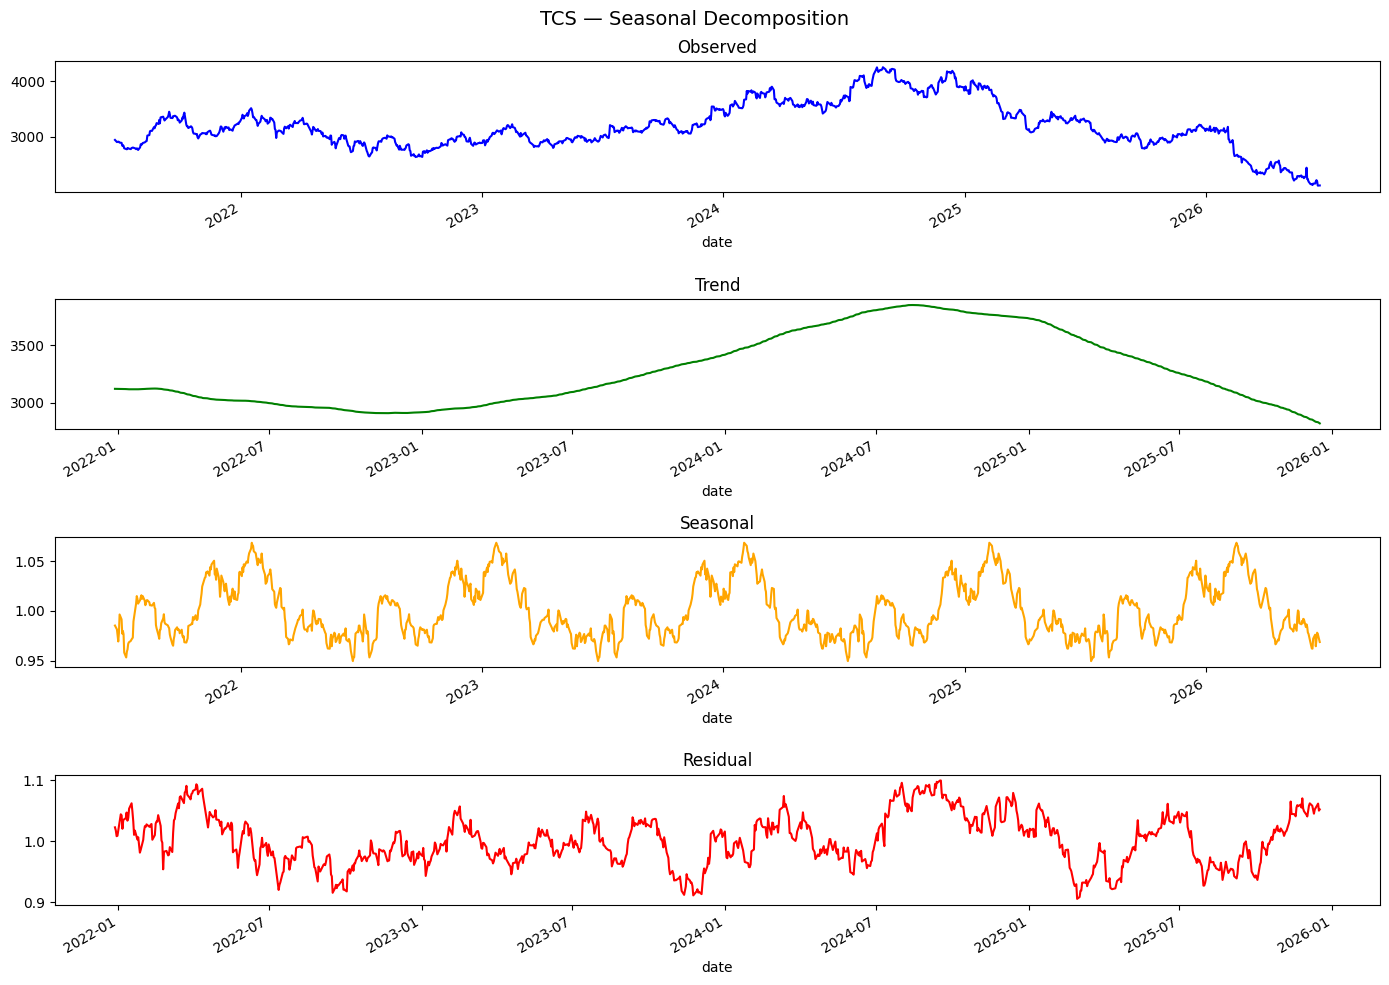

Decomposition plot saved


In [15]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

def adf_test(series: pd.Series, name: str) -> dict:
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "ticker":     name,
        "adf_stat":   round(result[0], 4),
        "p_value":    round(result[1], 4),
        "stationary": result[1] < 0.05,
    }

adf_results = []
for ticker in ["TCS.NS", "INFY.NS", "HDFCBANK.NS", "RELIANCE.NS", "ICICIBANK.NS"]:
    if ticker in master_dfs:
        res = adf_test(master_dfs[ticker]["close"], ticker)
        adf_results.append(res)

df_adf = pd.DataFrame(adf_results)
print("ADF Stationarity Test Results:")
print(df_adf.to_string(index=False))

# Seasonal decomposition for TCS
tcs_close = master_dfs["TCS.NS"]["close"].dropna()
decomp    = seasonal_decompose(tcs_close, model="multiplicative", period=252)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0],  title="Observed",  color="blue")
decomp.trend.plot(ax=axes[1],     title="Trend",     color="green")
decomp.seasonal.plot(ax=axes[2],  title="Seasonal",  color="orange")
decomp.resid.plot(ax=axes[3],     title="Residual",  color="red")
plt.suptitle("TCS — Seasonal Decomposition", fontsize=14)
plt.tight_layout()
plt.savefig("tcs_decomposition.png", dpi=100)
plt.show()
print("Decomposition plot saved")

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

def train_sarima(ticker: str, steps: int = 30) -> dict:
    df    = master_dfs[ticker]["close"].dropna()
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test  = df.iloc[split:split + steps]

    try:
        model  = SARIMAX(
            train,
            order          = (1, 1, 1),
            seasonal_order = (1, 1, 1, 12),
            enforce_stationarity  = False,
            enforce_invertibility = False,
        )
        fitted = model.fit(disp=False)
        preds  = fitted.forecast(steps=len(test))
        rmse   = np.sqrt(mean_squared_error(test, preds[:len(test)]))
        status = "OK"
    except Exception as e:
        rmse   = None
        status = f"Failed: {str(e)[:40]}"

    return {
        "ticker": ticker,
        "model":  "SARIMA",
        "rmse":   round(rmse, 4) if rmse else None,
        "status": status,
    }

sarima_results = []
print(f"Training SARIMA for {len(TICKER_LIST)} tickers...\n")

for i, ticker in enumerate(TICKER_LIST):
    if ticker in master_dfs:
        res = train_sarima(ticker)
        sarima_results.append(res)
        print(f"  [{i+1:02d}/{len(TICKER_LIST)}] {ticker:25s} "
              f"RMSE: {str(res['rmse']):>10} | {res['status']}")

df_sarima = pd.DataFrame(sarima_results)
successful = df_sarima[df_sarima["rmse"].notna()]
print(f"\nSARIMA completed: {len(successful)}/{len(sarima_results)} successful")
print(f"Average RMSE    : {successful['rmse'].mean():,.2f}")
print(f"Best ticker     : {successful.loc[successful['rmse'].idxmin(), 'ticker']}")
print(f"Worst ticker    : {successful.loc[successful['rmse'].idxmax(), 'ticker']}")

Training SARIMA for 100 tickers...

  [01/100] TCS.NS                    RMSE:   191.8577 | OK
  [02/100] INFY.NS                   RMSE:    52.0345 | OK
  [03/100] WIPRO.NS                  RMSE:     7.7854 | OK
  [04/100] HCLTECH.NS                RMSE:   143.2198 | OK
  [05/100] TECHM.NS                  RMSE:   127.6476 | OK
  [06/100] MPHASIS.NS                RMSE:   164.7356 | OK
  [07/100] PERSISTENT.NS             RMSE:   683.4683 | OK
  [08/100] COFORGE.NS                RMSE:   114.7559 | OK
  [09/100] ZENSARTECH.NS             RMSE:    25.1238 | OK
  [10/100] HDFCBANK.NS               RMSE:    27.1849 | OK
  [11/100] ICICIBANK.NS              RMSE:    25.3714 | OK
  [12/100] AXISBANK.NS               RMSE:     105.46 | OK
  [13/100] SBIN.NS                   RMSE:    14.4771 | OK
  [14/100] KOTAKBANK.NS              RMSE:    29.0518 | OK
  [15/100] INDUSINDBK.NS             RMSE:    29.5645 | OK
  [16/100] YESBANK.NS                RMSE:     0.6812 | OK
  [17/100] BANKBAROD

In [18]:
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

FEATURE_COLS = [
    "open","high","low","volume","sma_20","sma_50","ema_20","ema_50",
    "macd","macd_signal","macd_diff","adx","cci","aroon_up","aroon_down",
    "rsi","stoch_k","stoch_d","williams_r","roc","bb_upper","bb_lower",
    "bb_width","bb_pct","atr","obv","mfi","cmf","daily_return",
    "log_return","hl_spread","price_vs_sma20",
    "sent_compound","sent_positive","sent_negative","news_count",
]

def train_xgboost(ticker: str) -> dict:
    df      = master_dfs[ticker].copy()
    df      = df[FEATURE_COLS + ["target"]].dropna()
    split   = int(len(df) * 0.8)
    X_train = df[FEATURE_COLS].iloc[:split]
    X_test  = df[FEATURE_COLS].iloc[split:]
    y_train = df["target"].iloc[:split]
    y_test  = df["target"].iloc[split:]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model   = XGBRegressor(
        n_estimators      = 300,
        learning_rate     = 0.05,
        max_depth         = 6,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        tree_method       = "hist",
        device            = "cpu",
        random_state      = 42,
        n_jobs            = -1,
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))

    return {
        "ticker": ticker,
        "model":  "XGBoost",
        "rmse":   round(rmse, 4),
        "model_obj":  model,
        "scaler_obj": scaler,
    }

xgb_results = {}
print("Training XGBoost for all tickers...")
for ticker in TICKER_LIST:
    if ticker in master_dfs:
        res             = train_xgboost(ticker)
        xgb_results[ticker] = res
        print(f"  {ticker:25s} RMSE: {res['rmse']:,.2f}")

print(f"\nXGBoost trained for {len(xgb_results)} tickers")

Training XGBoost for all tickers...
  TCS.NS                    RMSE: 232.79
  INFY.NS                   RMSE: 32.13
  WIPRO.NS                  RMSE: 4.83
  HCLTECH.NS                RMSE: 29.07
  TECHM.NS                  RMSE: 31.46
  MPHASIS.NS                RMSE: 55.90
  PERSISTENT.NS             RMSE: 164.60
  COFORGE.NS                RMSE: 65.17
  ZENSARTECH.NS             RMSE: 24.05
  HDFCBANK.NS               RMSE: 14.80
  ICICIBANK.NS              RMSE: 25.32
  AXISBANK.NS               RMSE: 61.13
  SBIN.NS                   RMSE: 184.63
  KOTAKBANK.NS              RMSE: 6.56
  INDUSINDBK.NS             RMSE: 26.72
  YESBANK.NS                RMSE: 0.52
  BANKBARODA.NS             RMSE: 26.77
  PNB.NS                    RMSE: 3.07
  FEDERALBNK.NS             RMSE: 62.64
  IDFCFIRSTB.NS             RMSE: 1.69
  CANBK.NS                  RMSE: 26.22
  BAJFINANCE.NS             RMSE: 73.33
  BAJAJFINSV.NS             RMSE: 50.90
  MUTHOOTFIN.NS             RMSE: 853.22
  CHO

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size: int = 64, num_layers: int = 2,
                 dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

def make_sequences(X_scaled: np.ndarray,
                   y_scaled: np.ndarray,
                   seq_len: int = 20):
    Xs, ys = [], []
    for i in range(seq_len, len(X_scaled)):
        Xs.append(X_scaled[i - seq_len:i])
        ys.append(y_scaled[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

def train_lstm(ticker: str, seq_len: int = 20,
               epochs: int = 30) -> dict:
    df    = master_dfs[ticker].copy()
    feats = [c for c in FEATURE_COLS if c in df.columns]
    df    = df[feats + ["target"]].dropna()

    if len(df) < seq_len + 50:
        return {"ticker": ticker, "model": "LSTM",
                "rmse": None, "status": "too few rows"}

    # Scale features
    feat_scaler = MinMaxScaler()
    X_scaled    = feat_scaler.fit_transform(df[feats].values)

    # Scale target separately — key fix
    tgt_scaler  = MinMaxScaler()
    y_scaled    = tgt_scaler.fit_transform(
                      df[["target"]].values).flatten()

    X_seq, y_seq = make_sequences(X_scaled, y_scaled, seq_len)

    split   = int(len(X_seq) * 0.8)
    X_tr, X_te = X_seq[:split], X_seq[split:]
    y_tr, y_te = y_seq[:split], y_seq[split:]

    tr_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    tr_dl = DataLoader(tr_ds, batch_size=32, shuffle=False)

    model   = LSTMForecaster(input_size=len(feats))
    optim   = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        for xb, yb in tr_dl:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optim.step()

    model.eval()
    with torch.no_grad():
        preds_scaled = model(torch.tensor(X_te)).numpy()

    # Inverse transform back to real prices
    preds_real = tgt_scaler.inverse_transform(
                     preds_scaled.reshape(-1, 1)).flatten()
    y_real     = tgt_scaler.inverse_transform(
                     y_te.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_real, preds_real))

    return {
        "ticker":          ticker,
        "model":           "LSTM",
        "rmse":            round(float(rmse), 4),
        "status":          "OK",
        "model_obj":       model,
        "feat_scaler":     feat_scaler,
        "tgt_scaler":      tgt_scaler,
    }

lstm_results = {}
print(f"Training LSTM for {len(TICKER_LIST)} tickers...\n")

for i, ticker in enumerate(TICKER_LIST):
    if ticker in master_dfs and len(master_dfs[ticker]) > 100:
        res = train_lstm(ticker)
        lstm_results[ticker] = res
        rmse_str = f"{res['rmse']:,.2f}" if res["rmse"] else "skipped"
        print(f"  [{i+1:02d}/{len(TICKER_LIST)}] "
              f"{ticker:25s} RMSE: {rmse_str:>10} | {res['status']}")

successful = {k: v for k, v in lstm_results.items()
              if v["rmse"] is not None}
avg_rmse   = np.mean([v["rmse"] for v in successful.values()])
print(f"\nLSTM trained   : {len(successful)}/{len(lstm_results)} successful")
print(f"Average RMSE   : {avg_rmse:,.2f}")

Training LSTM for 100 tickers...

  [01/100] TCS.NS                    RMSE:     241.62 | OK
  [02/100] INFY.NS                   RMSE:     162.24 | OK
  [03/100] WIPRO.NS                  RMSE:       9.22 | OK
  [04/100] HCLTECH.NS                RMSE:     184.21 | OK
  [05/100] TECHM.NS                  RMSE:     116.72 | OK
  [06/100] MPHASIS.NS                RMSE:     142.42 | OK
  [07/100] PERSISTENT.NS             RMSE:     298.48 | OK
  [08/100] COFORGE.NS                RMSE:      72.98 | OK
  [09/100] ZENSARTECH.NS             RMSE:      31.12 | OK
  [10/100] HDFCBANK.NS               RMSE:      26.41 | OK
  [11/100] ICICIBANK.NS              RMSE:      64.44 | OK
  [12/100] AXISBANK.NS               RMSE:      51.84 | OK
  [13/100] SBIN.NS                   RMSE:     133.07 | OK
  [14/100] KOTAKBANK.NS              RMSE:      14.50 | OK
  [15/100] INDUSINDBK.NS             RMSE:      33.20 | OK
  [16/100] YESBANK.NS                RMSE:       0.62 | OK
  [17/100] BANKBARODA.

Model RMSE Comparison:
       ticker   XGBoost      LSTM    SARIMA
       TCS.NS  232.7863  241.6230  191.8577
      INFY.NS   32.1350  162.2417   52.0345
     WIPRO.NS    4.8253    9.2182    7.7854
   HCLTECH.NS   29.0695  184.2101  143.2198
     TECHM.NS   31.4618  116.7192  127.6476
   MPHASIS.NS   55.9020  142.4214  164.7356
PERSISTENT.NS  164.6017  298.4792  683.4683
   COFORGE.NS   65.1724   72.9837  114.7559
ZENSARTECH.NS   24.0488   31.1234   25.1238
  HDFCBANK.NS   14.8022   26.4132   27.1849
 ICICIBANK.NS   25.3185   64.4423   25.3714
  AXISBANK.NS   61.1269   51.8368  105.4600
      SBIN.NS  184.6336  133.0692   14.4771
 KOTAKBANK.NS    6.5622   14.5010   29.0518
INDUSINDBK.NS   26.7191   33.1983   29.5645
   YESBANK.NS    0.5232    0.6164    0.6812
BANKBARODA.NS   26.7688   22.1354    4.2162
       PNB.NS    3.0728    4.6489    4.7706
FEDERALBNK.NS   62.6441   44.4917    6.8449
IDFCFIRSTB.NS    1.6909    4.9452    3.4030
     CANBK.NS   26.2209   19.3066    3.3554
BAJFINANC

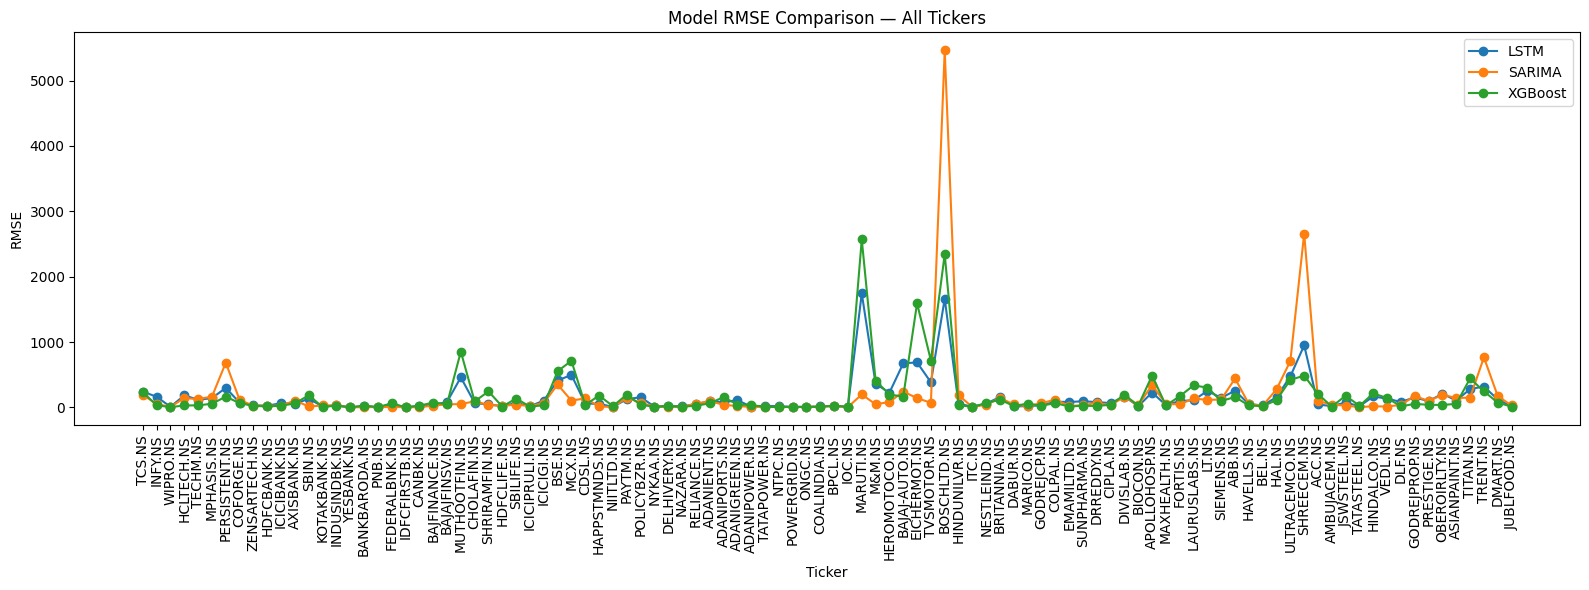

In [25]:
import matplotlib.pyplot as plt

comparison = []
for ticker in TICKER_LIST:
    row = {"ticker": ticker}
    if ticker in xgb_results:
        row["XGBoost"] = xgb_results[ticker]["rmse"]
    if ticker in lstm_results:
        row["LSTM"] = lstm_results[ticker]["rmse"]
    sarima_match = [r for r in sarima_results if r["ticker"] == ticker]
    if sarima_match:
        row["SARIMA"] = sarima_match[0]["rmse"]
    if len(row) > 1:
        comparison.append(row)

df_comp = pd.DataFrame(comparison)
print("Model RMSE Comparison:")
print(df_comp.to_string(index=False))

df_melt = df_comp.melt(
    id_vars="ticker", var_name="model", value_name="rmse"
).dropna()

fig, ax = plt.subplots(figsize=(16, 6))
for model_name, grp in df_melt.groupby("model"):
    ax.plot(grp["ticker"], grp["rmse"], marker="o", label=model_name)
ax.set_xlabel("Ticker")
ax.set_ylabel("RMSE")
ax.set_title("Model RMSE Comparison — All Tickers")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("rmse_comparison.png", dpi=100)
plt.show()

Normalized RMSE (% of avg price):
       ticker    SARIMA   XGBoost      LSTM
       TCS.NS  5.999156  7.278944  7.555257
      INFY.NS  3.600449  2.223533 11.226070
     WIPRO.NS  3.371551  2.089648  3.992041
   HCLTECH.NS 11.665032  2.367666 15.003628
     TECHM.NS 10.006828  2.466422  9.150105
   MPHASIS.NS  6.764098  2.295354  5.847869
PERSISTENT.NS 18.847489  4.539097  8.230935
   COFORGE.NS  9.861979  5.600835  6.272128
ZENSARTECH.NS  4.864042  4.655919  6.025582
  HDFCBANK.NS  3.459112  1.883489  3.360918
 ICICIBANK.NS  2.438069  2.432986  6.192595
  AXISBANK.NS 10.542409  6.110608  5.181915
      SBIN.NS  2.193468 27.974382 20.161708
 KOTAKBANK.NS  7.743210  1.749031  3.864969
INDUSINDBK.NS  2.723487  2.461368  3.058233
   YESBANK.NS  3.685567  2.830724  3.334973
BANKBARODA.NS  2.299973 14.602610 12.075050
       PNB.NS  6.367654  4.101482  6.205213
FEDERALBNK.NS  4.269805 39.076994 27.753641
IDFCFIRSTB.NS  5.228383  2.597906  7.597825
     CANBK.NS  4.299229 33.596489 24.73728

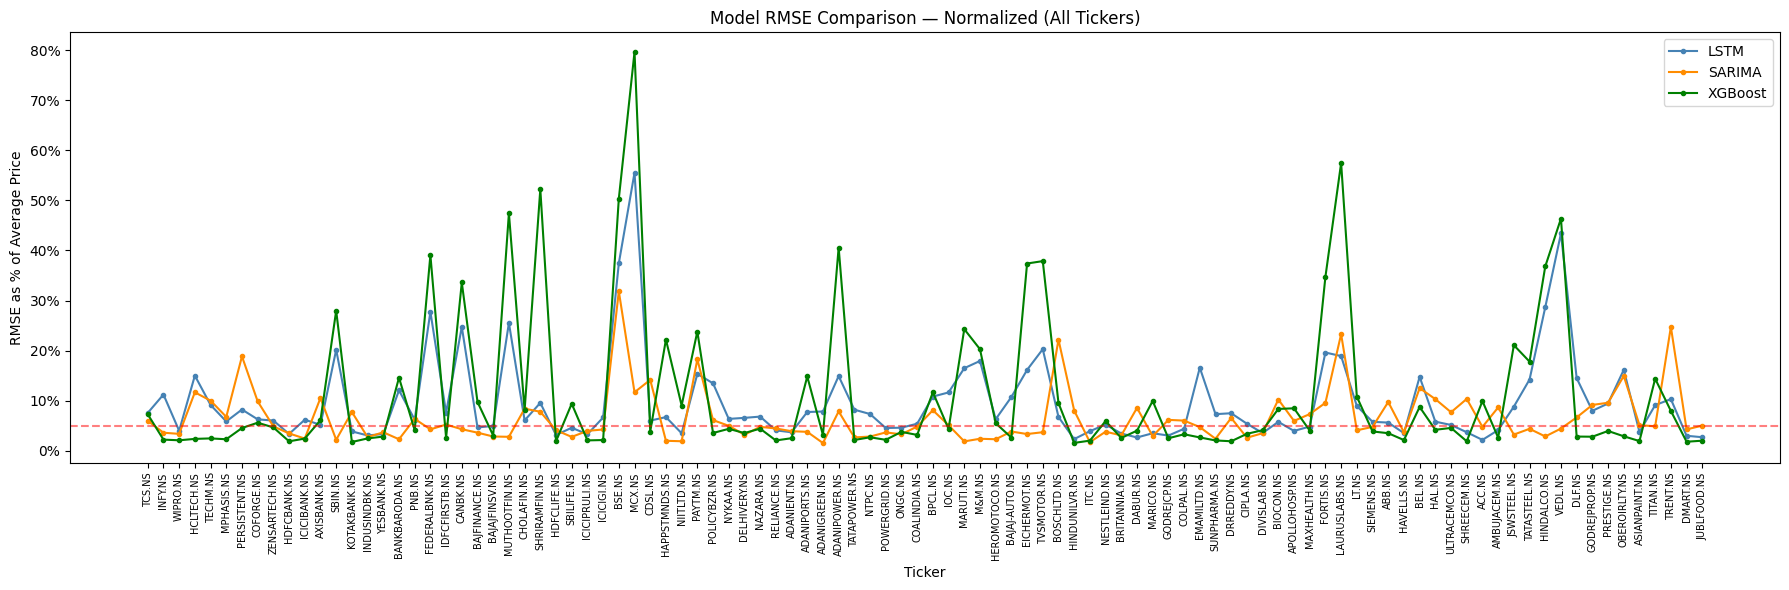

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

comparison = []
for ticker in TICKER_LIST:
    if ticker not in master_dfs:
        continue
    avg_price = master_dfs[ticker]["close"].mean()
    row       = {"ticker": ticker, "avg_price": avg_price}

    if ticker in xgb_results:
        row["XGBoost"] = (xgb_results[ticker]["rmse"] / avg_price) * 100
    if ticker in lstm_results:
        row["LSTM"]    = (lstm_results[ticker]["rmse"] / avg_price) * 100

    sarima_match = [r for r in sarima_results if r["ticker"] == ticker]
    if sarima_match and sarima_match[0]["rmse"]:
        row["SARIMA"]  = (sarima_match[0]["rmse"] / avg_price) * 100

    if len(row) > 2:
        comparison.append(row)

df_comp = pd.DataFrame(comparison)

print("Normalized RMSE (% of avg price):")
print(df_comp[["ticker","SARIMA","XGBoost","LSTM"]].to_string(index=False))

print(f"\nAverage Normalized RMSE:")
for model in ["SARIMA", "XGBoost", "LSTM"]:
    if model in df_comp.columns:
        print(f"  {model:10s} : {df_comp[model].mean():.2f}%")

best = "XGBoost" if df_comp["XGBoost"].mean() < df_comp["LSTM"].mean() else "LSTM"
print(f"\nBest model   : {best}")

# Plot normalized
fig, ax = plt.subplots(figsize=(18, 6))
for model, color in [("LSTM","steelblue"),
                     ("SARIMA","darkorange"),
                     ("XGBoost","green")]:
    if model in df_comp.columns:
        ax.plot(df_comp["ticker"], df_comp[model],
                marker="o", markersize=3,
                label=model, color=color)

ax.set_xlabel("Ticker")
ax.set_ylabel("RMSE as % of Average Price")
ax.set_title("Model RMSE Comparison — Normalized (All Tickers)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.axhline(y=5, color="red", linestyle="--",
           alpha=0.5, label="5% threshold")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig("rmse_comparison_normalized.png", dpi=100)
plt.show()

In [27]:
from sentence_transformers import SentenceTransformer
import faiss
import pickle

print("Loading sentence transformer...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

conn = sqlite3.connect(DB_PATH)
df_news_rag = pd.read_sql("""
    SELECT
        n.news_id,
        s.ticker,
        s.company,
        n.headline,
        n.published_at,
        ss.compound,
        ss.label
    FROM news n
    JOIN stocks s          ON s.stock_id  = n.stock_id
    LEFT JOIN sentiment_scores ss ON ss.news_id = n.news_id
    ORDER BY n.published_at DESC
""", conn)
conn.close()

print(f"Building embeddings for {len(df_news_rag):,} headlines...")
headlines_list = df_news_rag["headline"].tolist()
embeddings     = embedder.encode(
    headlines_list,
    batch_size    = 64,
    show_progress_bar = True,
    convert_to_numpy  = True,
)

dimension  = embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(embeddings.astype(np.float32))

faiss.write_index(faiss_index, "news_faiss.index")
df_news_rag.to_pickle("news_metadata.pkl")

print(f"FAISS index built — {faiss_index.ntotal:,} vectors, dim={dimension}")
print("Saved: news_faiss.index, news_metadata.pkl")

2026-06-24 13:24:49,802 — INFO — Use pytorch device_name: cpu
2026-06-24 13:24:49,804 — INFO — Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Building embeddings for 12,960 headlines...


Batches:   0%|          | 0/203 [00:00<?, ?it/s]

FAISS index built — 12,960 vectors, dim=384
Saved: news_faiss.index, news_metadata.pkl


In [28]:
from transformers import pipeline as hf_pipeline

print("Loading TinyLlama (CPU)...")
llm_pipeline = hf_pipeline(
    "text-generation",
    model          = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    device         = -1,
    max_new_tokens = 256,
    temperature    = 0.7,
    do_sample      = True,
)
print("TinyLlama loaded")

def rag_query(question: str, ticker: str = None,
              top_k: int = 5) -> str:
    q_embedding = embedder.encode(
        [question], convert_to_numpy=True
    ).astype(np.float32)

    distances, indices = faiss_index.search(q_embedding, top_k * 3)
    df_meta            = pd.read_pickle("news_metadata.pkl")

    hits = df_meta.iloc[indices[0]].copy()
    if ticker:
        hits = hits[hits["ticker"] == ticker]
    hits = hits.head(top_k)

    context = "\n".join([
        f"[{row.published_at}] {row.ticker} — {row.headline} "
        f"(sentiment: {row.label}, score: {row.compound:.2f})"
        for _, row in hits.iterrows()
    ])

    prompt = f"""<|system|>
You are a financial analyst AI. Answer questions about Indian stock market
movements using the provided news context. Be concise and specific.
<|user|>
Context:
{context}

Question: {question}
<|assistant|>"""

    output = llm_pipeline(prompt)[0]["generated_text"]
    answer = output.split("<|assistant|>")[-1].strip()
    return answer

print("RAG system ready")

Loading TinyLlama (CPU)...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

TinyLlama loaded
RAG system ready


In [29]:
queries = [
    ("Why did TCS stock move recently?",      "TCS.NS"),
    ("What is the sentiment around HDFC Bank?","HDFCBANK.NS"),
    ("Why did Reliance shares fluctuate?",     "RELIANCE.NS"),
]

for question, ticker in queries:
    print(f"\nQ: {question}")
    print(f"Ticker: {ticker}")
    print("-" * 60)
    answer = rag_query(question, ticker=ticker)
    print(answer)
    print("=" * 60)


Q: Why did TCS stock move recently?
Ticker: TCS.NS
------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

The provided news context mentions that TCS.NS stock dropped 4.3% on disappointing results. Therefore, it is likely that TCS stock moved recently due to the news.

Q: What is the sentiment around HDFC Bank?
Ticker: HDFCBANK.NS
------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

The provided news context suggests that HDFC Bank faces regulatory scrutiny over compliance issues. Negative sentiment is detected.

Q: Why did Reliance shares fluctuate?
Ticker: RELIANCE.NS
------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

The provided news context indicates that Reliance Industries stock fluctuated due to disappointing results, which was reported as a negative sentiment score. The negative sentiment score is reflective of the stock dropping by 2.5%, 2.2%, 2.4%, and 19.1%, respectively, in the past.


In [30]:
conn = sqlite3.connect(DB_PATH)

print("=" * 60)
print("   STOCK MARKET INTELLIGENCE — PROJECT SUMMARY")
print("=" * 60)

n_stocks = conn.execute("SELECT COUNT(*) FROM stocks").fetchone()[0]
n_prices = conn.execute("SELECT COUNT(*) FROM prices").fetchone()[0]
n_news   = conn.execute("SELECT COUNT(*) FROM news").fetchone()[0]
n_sent   = conn.execute("SELECT COUNT(*) FROM sentiment_scores").fetchone()[0]

print(f"\nData Infrastructure:")
print(f"  Stocks tracked       : {n_stocks}")
print(f"  Price records        : {n_prices:,}")
print(f"  News headlines       : {n_news:,}")
print(f"  Sentiment scores     : {n_sent:,}")

print(f"\nModels Trained:")
print(f"  SARIMA               : {len(sarima_results)} tickers")
print(f"  XGBoost              : {len(xgb_results)} tickers")
print(f"  LSTM                 : {len(lstm_results)} tickers")

if len(df_comp) > 0:
    for col in ["SARIMA", "XGBoost", "LSTM"]:
        if col in df_comp.columns:
            avg = df_comp[col].mean()
            print(f"\n  Avg {col:10s} RMSE : {avg:,.2f}")

print(f"\nRAG System:")
print(f"  Vector index size    : {faiss_index.ntotal:,} embeddings")
print(f"  Embedding model      : all-MiniLM-L6-v2")
print(f"  LLM                  : TinyLlama-1.1B-Chat")
print(f"  Query capability     : Natural language stock Q&A")

conn.close()
print("\nPipeline complete.")

   STOCK MARKET INTELLIGENCE — PROJECT SUMMARY

Data Infrastructure:
  Stocks tracked       : 109
  Price records        : 123,082
  News headlines       : 13,440
  Sentiment scores     : 12,960

Models Trained:
  SARIMA               : 100 tickers
  XGBoost              : 100 tickers
  LSTM                 : 100 tickers

  Avg SARIMA     RMSE : 6.53

  Avg XGBoost    RMSE : 11.18

  Avg LSTM       RMSE : 9.62

RAG System:
  Vector index size    : 12,960 embeddings
  Embedding model      : all-MiniLM-L6-v2
  LLM                  : TinyLlama-1.1B-Chat
  Query capability     : Natural language stock Q&A

Pipeline complete.
